# Chapter 1: Historical Analysis of Centum Electronics

## Step 1: Data Loading and Validation
Note: All financial figures are presented in ₹ Million unless otherwise stated.

In [1]:
import pandas as pd

file_path = "CCC_DATA.xlsx"

all_sheets = pd.read_excel(file_path, sheet_name=None)

print("Sheets Loaded:")
print(list(all_sheets.keys()))

Sheets Loaded:
['Centum', 'Astra', 'Datapatterns', 'Kaynes Technolgies', 'Apollo Micro Sysyems']



## Step 2: Extract Centum Data

In [2]:
# Extract Centum data

centum = all_sheets["Centum"]

print("Rows:", centum.shape[0])
print("Columns:", centum.shape[1])

centum.head()

Rows: 11
Columns: 11


,Finacial Year,Statement_Date,Revenue(M),COGS(M),Inventory(M),Receivables(M),Payables(M),DSO(Days),DIO(Days),DPO(Days),CCC(Days)
0,FY2015,2016-03-31,3316.689,2113.702,1328.604,887.559,604.288,96.337414,226.284235,102.920696,219.700953
1,FY2016,2017-03-31,3872.526,2464.621,1633.850,919.994,782.860,85.525014,238.651703,114.350077,209.826641
2,FY2017,2018-03-31,3587.079,2536.084,2473.121,947.571,1133.028,95.098424,351.062331,160.834610,285.326145
3,FY2018,2019-03-31,5058.283,3135.190,2251.232,1862.663,1063.349,132.566462,258.499013,122.099662,268.965812
4,FY2019,2020-03-31,4823.780,2803.510,2204.060,1699.650,1139.050,126.845337,283.024352,146.265931,263.603758


## Step 3: Review Dataset Structure and Data Types

In [3]:
# Review structure of Centum dataset

centum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Finacial Year   11 non-null     object        
 1   Statement_Date  11 non-null     datetime64[ns]
 2   Revenue(M)      11 non-null     float64       
 3   COGS(M)         11 non-null     float64       
 4   Inventory(M)    11 non-null     float64       
 5   Receivables(M)  11 non-null     float64       
 6   Payables(M)     11 non-null     float64       
 7   DSO(Days)       11 non-null     float64       
 8   DIO(Days)       11 non-null     float64       
 9   DPO(Days)       11 non-null     float64       
 10  CCC(Days)       11 non-null     float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 1.1+ KB


## Step 4: Data Quality Check and Missing Value Analysis

In [4]:
# Check for missing values

centum.isnull().sum()

Finacial Year     0
Statement_Date    0
Revenue(M)        0
COGS(M)           0
Inventory(M)      0
Receivables(M)    0
Payables(M)       0
DSO(Days)         0
DIO(Days)         0
DPO(Days)         0
CCC(Days)         0
dtype: int64

## Step 5: Descriptive Statistics of Centum Dataset

In [5]:
# Descriptive statistics for numerical variables

centum.describe().round(2)

,Statement_Date,Revenue(M),COGS(M),Inventory(M),Receivables(M),Payables(M),DSO(Days),DIO(Days),DPO(Days),CCC(Days)
count,11,11.00,11.00,11.00,11.00,11.00,11.00,11.00,11.00,11.00
mean,2021-03-30 21:49:05.454545408,5176.93,3301.76,2422.57,1701.27,1219.72,113.94,269.70,130.93,252.72
min,2016-03-31 00:00:00,3316.69,2032.75,1328.60,887.56,587.77,84.47,226.28,83.75,209.83
25%,2018-09-29 12:00:00,3729.80,2495.56,1866.03,933.78,754.54,93.62,243.68,117.43,229.43
50%,2021-03-31 00:00:00,4823.78,2803.51,2251.23,1699.65,1133.03,113.69,256.44,128.62,249.44
75%,2023-09-30 00:00:00,5693.13,3595.50,2673.64,2148.75,1587.34,129.71,273.58,146.73,268.46
max,2026-03-31 00:00:00,9730.56,6567.99,4567.76,3139.10,2549.37,150.71,351.82,173.93,315.34
std,NaN,1976.22,1382.86,898.81,858.86,590.56,24.82,43.08,26.07,31.33


## Step 6: Revenue Trend Analysis

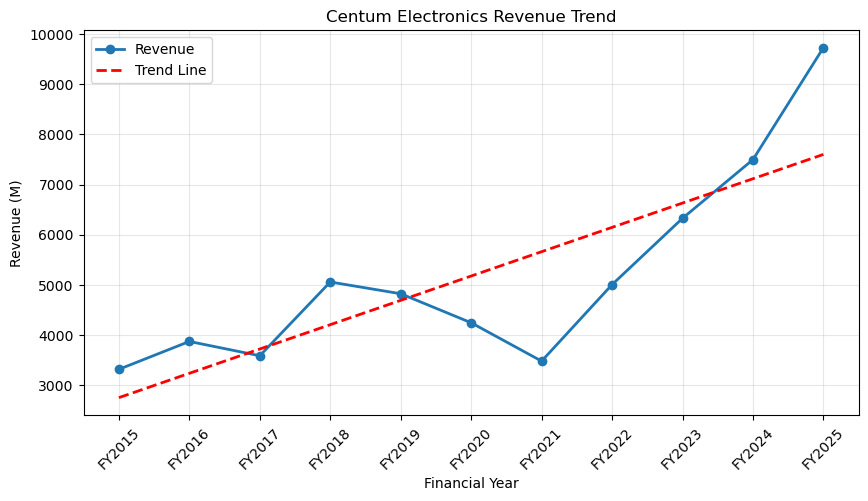

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# Revenue trend
plt.plot(
    centum["Finacial Year"],
    centum["Revenue(M)"],
    marker="o",
    linewidth=2,
    label="Revenue"
)

# Create trend line
x = np.arange(len(centum))  # Numeric index for years
y = centum["Revenue(M)"]

z = np.polyfit(x, y, 1)      # 1 = linear trendline
p = np.poly1d(z)

plt.plot(
    centum["Finacial Year"],
    p(x),
    linestyle="--",
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Centum Electronics Revenue Trend")
plt.xlabel("Financial Year")
plt.ylabel("Revenue (M)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [7]:
centum["Linear Forecast"] = p(x)

In [8]:
centum[["Finacial Year","Revenue(M)","Linear Forecast"]]

,Finacial Year,Revenue(M),Linear Forecast
0,FY2015,3316.689,2752.094364
1,FY2016,3872.526,3237.060891
2,FY2017,3587.079,3722.027418
3,FY2018,5058.283,4206.993945
4,FY2019,4823.780,4691.960473
5,FY2020,4245.270,5176.927000
6,FY2021,3480.110,5661.893527
7,FY2022,5005.540,6146.860055
8,FY2023,6327.980,6631.826582
9,FY2024,7498.380,7116.793109


In [9]:
fy26_forecast = p(len(centum))
print(fy26_forecast)
fy27_forecast = p(len(centum) + 1)
print(fy27_forecast)
fy28_forecast = p(len(centum) + 2)
print(fy28_forecast)

8086.726163636362
8571.692690909089
9056.659218181816


In [10]:
forecast_table = pd.DataFrame({
    "Finacial Year": ["FY2026", "FY2027", "FY2028"],
    "Linear Forecast": [
        fy26_forecast,
        fy27_forecast,
        fy28_forecast
    ]
})

forecast_table

,Finacial Year,Linear Forecast
0,FY2026,8086.726164
1,FY2027,8571.692691
2,FY2028,9056.659218


In [11]:
future_df = pd.DataFrame({
    "Finacial Year": ["FY2026", "FY2027", "FY2028"],
    "Revenue(M)": [np.nan, np.nan, np.nan],
    "Linear Forecast": [
        fy26_forecast,
        fy27_forecast,
        fy28_forecast
    ]
})

centum_extended = pd.concat(
    [centum, future_df],
    ignore_index=True
)

centum_extended

,Finacial Year,Statement_Date,Revenue(M),COGS(M),Inventory(M),Receivables(M),Payables(M),DSO(Days),DIO(Days),DPO(Days),CCC(Days),Linear Forecast
0,FY2015,2016-03-31,3316.689,2113.702,1328.604,887.559,604.288,96.337414,226.284235,102.920696,219.700953,2752.094364
1,FY2016,2017-03-31,3872.526,2464.621,1633.850,919.994,782.860,85.525014,238.651703,114.350077,209.826641,3237.060891
2,FY2017,2018-03-31,3587.079,2536.084,2473.121,947.571,1133.028,95.098424,351.062331,160.834610,285.326145,3722.027418
3,FY2018,2019-03-31,5058.283,3135.190,2251.232,1862.663,1063.349,132.566462,258.499013,122.099662,268.965812,4206.993945
4,FY2019,2020-03-31,4823.780,2803.510,2204.060,1699.650,1139.050,126.845337,283.024352,146.265931,263.603758,4691.960473
5,FY2020,2021-03-31,4245.270,2526.490,1745.490,996.160,587.770,84.474627,248.715174,83.751450,249.438351,5176.927000
6,FY2021,2022-03-31,3480.110,2032.750,1986.570,890.670,726.230,92.135364,351.821523,128.615324,315.341562,5661.893527
7,FY2022,2023-03-31,5005.540,3156.100,2315.710,2094.870,1524.850,150.663705,264.141060,173.931751,240.873014,6146.860055
8,FY2023,2024-03-31,6327.980,4034.910,2874.160,2202.630,1649.840,125.308045,256.436352,147.200904,234.543492,6631.826582
9,FY2024,2025-03-31,7498.380,4947.970,3267.740,3139.100,1656.300,150.709353,237.751320,120.507602,267.953071,7116.793109


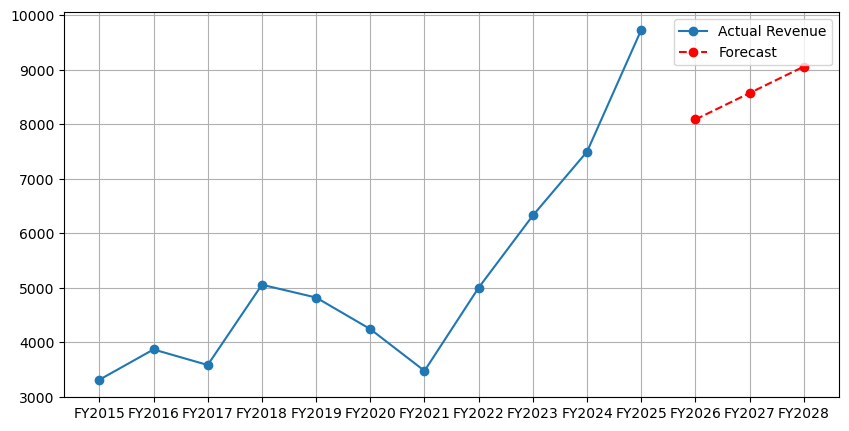

In [12]:
plt.figure(figsize=(10,5))

# Actual Revenue
plt.plot(
    centum["Finacial Year"],
    centum["Revenue(M)"],
    marker="o",
    label="Actual Revenue"
)

# Future Forecast
future_years = ["FY2026", "FY2027", "FY2028"]

future_values = [
    fy26_forecast,
    fy27_forecast,
    fy28_forecast
]

plt.plot(
    future_years,
    future_values,
    marker="o",
    linestyle="--",
    color="red",
    label="Forecast"
)

plt.legend()
plt.grid(True)
plt.show()

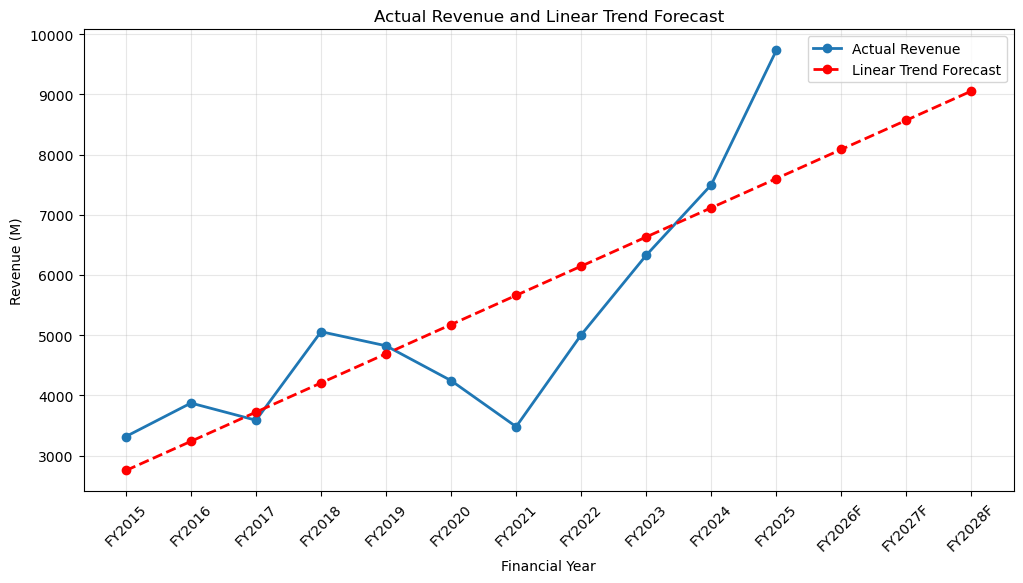

In [13]:
# Historical fitted values
historical_fit = p(x)

# Future forecasts
future_x = np.arange(len(centum), len(centum)+3)
future_fit = p(future_x)

# Combine
all_forecast = np.concatenate([historical_fit, future_fit])

# Labels
all_years = list(centum["Finacial Year"]) + [
    "FY2026F",
    "FY2027F",
    "FY2028F"
]

plt.figure(figsize=(12,6))

plt.plot(
    centum["Finacial Year"],
    centum["Revenue(M)"],
    marker="o",
    linewidth=2,
    label="Actual Revenue"
)

plt.plot(
    all_years,
    all_forecast,
    marker="o",
    linestyle="--",
    linewidth=2,
    color="red",
    label="Linear Trend Forecast"
)

plt.title("Actual Revenue and Linear Trend Forecast")
plt.xlabel("Financial Year")
plt.ylabel("Revenue (M)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

SLope R^2

In [14]:
x = np.arange(len(centum))
y = centum["Revenue(M)"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
slope = z[0]
intercept = z[1]
r2 = np.corrcoef(y, p(x))[0,1]**2
print("Slope :", round(slope,2))
print("Intercept :", round(intercept,2))
print("R² =", round(r2,4))

Slope : 484.97
Intercept : 2752.09
R² = 0.6624


In [15]:
import numpy as np

Linear_Error = centum["Revenue(M)"] - centum["Linear Forecast"]

Linear_mae = np.mean(np.abs(Linear_Error))

Linear_mape = np.mean(
    np.abs(Linear_Error / centum["Revenue(M)"])
) * 100

Linear_rmse = np.sqrt(
    np.mean(Linear_Error**2)
)

print("Linear-MAE :", round(Linear_mae,2))
print("Linear-MAPE:", round(Linear_mape,2))
print("Linear-RMSE:", round(Linear_rmse,2))

linear_metrics = pd.DataFrame({
    "Metric": ["Linear-MAE","Linear-MAPE","Linear-RMSE"],
    "Value": [Linear_mae,Linear_mape,Linear_rmse]
})

print(linear_metrics)

Linear-MAE : 853.37
Linear-MAPE: 17.81
Linear-RMSE: 1094.75
        Metric        Value
0   Linear-MAE   853.373742
1  Linear-MAPE    17.814970
2  Linear-RMSE  1094.754493


SES

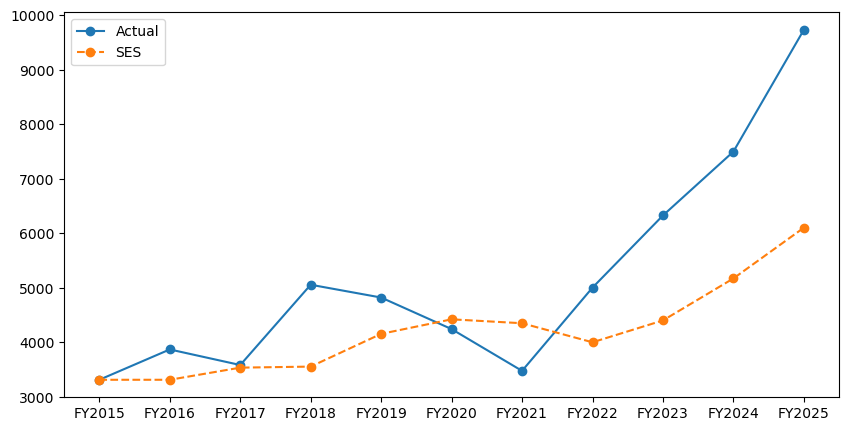

In [16]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
ses_model = SimpleExpSmoothing(
    centum["Revenue(M)"]
).fit(
    smoothing_level=0.4,
    optimized=False
)
centum["SES Forecast"] = ses_model.fittedvalues
plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Revenue(M)"],
    marker="o",
    label="Actual"
)

plt.plot(
    centum["Finacial Year"],
    centum["SES Forecast"],
    marker="o",
    linestyle="--",
    label="SES"
)

plt.legend()
plt.show()

In [17]:
import numpy as np

SES_Error = centum["Revenue(M)"] - centum["SES Forecast"]

SES_mae = np.mean(np.abs(SES_Error))

SES_mape = np.mean(
    np.abs(SES_Error / centum["Revenue(M)"])
) * 100

SES_rmse = np.sqrt(
    np.mean(SES_Error**2)
)

print("SES-MAE :", round(SES_mae,2))
print("SES-MAPE:", round(SES_mape,2))
print("SES-RMSE:", round(SES_rmse,2))

ses_metrics = pd.DataFrame({
    "Metric": ["SES-MAE","SES-MAPE","SES-RMSE"],
    "Value": [SES_mae, SES_mape, SES_rmse]
})

ses_metrics

SES-MAE : 1154.37
SES-MAPE: 18.83
SES-RMSE: 1568.42


,Metric,Value
0,SES-MAE,1154.372217
1,SES-MAPE,18.829736
2,SES-RMSE,1568.419639


DES

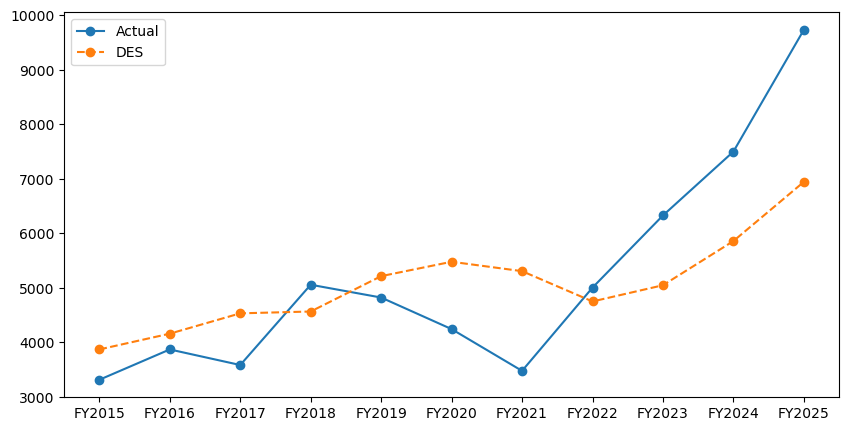

In [18]:
from statsmodels.tsa.holtwinters import Holt
des_model = Holt(
    centum["Revenue(M)"]
).fit(
    smoothing_level=0.4,
    smoothing_trend=0.2,
    optimized=False
)
centum["DES Forecast"] = des_model.fittedvalues
plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Revenue(M)"],
    marker="o",
    label="Actual"
)

plt.plot(
    centum["Finacial Year"],
    centum["DES Forecast"],
    marker="o",
    linestyle="--",
    label="DES"
)

plt.legend()
plt.show()

In [19]:
import numpy as np

DES_Error = centum["Revenue(M)"] - centum["DES Forecast"]

DES_mae = np.mean(np.abs(DES_Error))

DES_mape = np.mean(
    np.abs(DES_Error / centum["Revenue(M)"])
) * 100

DES_rmse = np.sqrt(
    np.mean(DES_Error**2)
)

print("DES-MAE :", round(DES_mae,2))
print("DES-MAPE:", round(DES_mape,2))
print("DES-RMSE:", round(DES_rmse,2))

des_metrics = pd.DataFrame({
    "Metric": ["DES-MAE","DES-MAPE","DES-RMSE"],
    "Value": [DES_mae, DES_mape, DES_rmse]
})

des_metrics

DES-MAE : 1063.14
DES-MAPE: 20.53
DES-RMSE: 1303.83


,Metric,Value
0,DES-MAE,1063.142309
1,DES-MAPE,20.527593
2,DES-RMSE,1303.825156


In [20]:
revenue_summary = pd.DataFrame({
    "Model": [
        "Linear Trend",
        "SES (α=0.4)",
        "DES (α=0.4, β=0.2)"
    ],
    "MAE": [
        Linear_mae,
        SES_mae,
        DES_mae
    ],
    "MAPE (%)": [
        Linear_mape,
        SES_mape,
        DES_mape
    ],
    "RMSE": [
        Linear_rmse,
        SES_rmse,
        DES_rmse
    ]
})

revenue_summary = revenue_summary.round(2)

print(revenue_summary)

                Model      MAE  MAPE (%)     RMSE
0        Linear Trend   853.37     17.81  1094.75
1         SES (α=0.4)  1154.37     18.83  1568.42
2  DES (α=0.4, β=0.2)  1063.14     20.53  1303.83


In [21]:
revenue_model_selection = (
    revenue_summary
    .sort_values(
        ["MAPE (%)", "MAE", "RMSE"]
    )
    .head(1)
    [["Model", "MAE", "MAPE (%)", "RMSE"]]
)

print(revenue_model_selection)

          Model     MAE  MAPE (%)     RMSE
0  Linear Trend  853.37     17.81  1094.75


### 7.3 Revenue Growth Analysis

The revenue trend of Centum Electronics was analysed for the period FY2016 to FY2026. Revenue increased from approximately 3,317 million in FY2016 to 9,731 million in FY2026, indicating significant business growth over the study period. The highest revenue was recorded in FY2026, while FY2016 represented the lowest revenue level in the dataset. Although some fluctuations were observed during intermediate years, the overall revenue trend remained positive, reflecting expansion in business operations and improved market performance.

In [22]:
# Year-on-Year Revenue Growth

centum["Revenue_Growth_%"] = centum["Revenue(M)"].pct_change() * 100

centum[["Finacial Year", "Revenue(M)", "Revenue_Growth_%"]]


,Finacial Year,Revenue(M),Revenue_Growth_%
0,FY2015,3316.689,NaN
1,FY2016,3872.526,16.758792
2,FY2017,3587.079,-7.371080
3,FY2018,5058.283,41.013984
4,FY2019,4823.780,-4.636020
5,FY2020,4245.270,-11.992877
6,FY2021,3480.110,-18.023824
7,FY2022,5005.540,43.832810
8,FY2023,6327.980,26.419527
9,FY2024,7498.380,18.495634


## Step 8: Inventory Trend Analysis

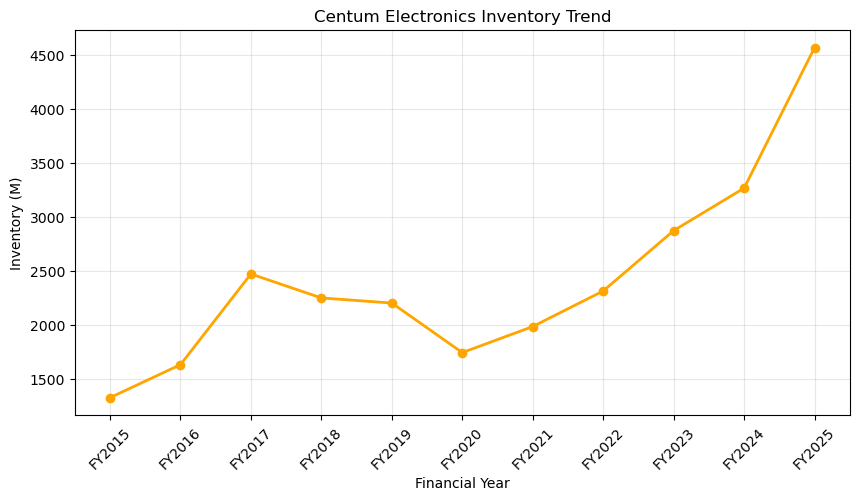

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Inventory(M)"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.title("Centum Electronics Inventory Trend")
plt.xlabel("Financial Year")
plt.ylabel("Inventory (M)")
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.show()

### 1.4.1 Inventory as a Percentage of Revenue

In [24]:
# Inventory as % of Revenue

centum["Inventory_to_Revenue_%"] = (
    centum["Inventory(M)"] / centum["Revenue(M)"]
) * 100

centum[[
    "Finacial Year",
    "Inventory(M)",
    "Revenue(M)",
    "Inventory_to_Revenue_%"
]].round(2)

,Finacial Year,Inventory(M),Revenue(M),Inventory_to_Revenue_%
0,FY2015,1328.60,3316.69,40.06
1,FY2016,1633.85,3872.53,42.19
2,FY2017,2473.12,3587.08,68.95
3,FY2018,2251.23,5058.28,44.51
4,FY2019,2204.06,4823.78,45.69
5,FY2020,1745.49,4245.27,41.12
6,FY2021,1986.57,3480.11,57.08
7,FY2022,2315.71,5005.54,46.26
8,FY2023,2874.16,6327.98,45.42
9,FY2024,3267.74,7498.38,43.58


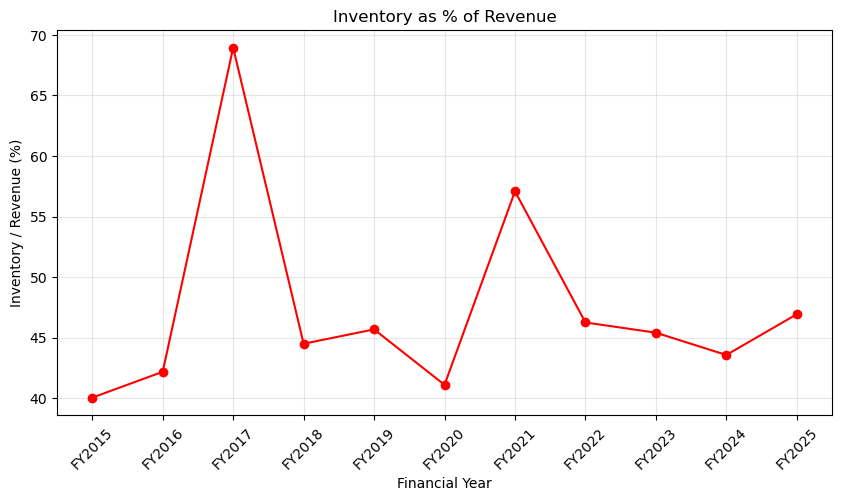

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Inventory_to_Revenue_%"],
    marker="o",
    color="red"
)

plt.title("Inventory as % of Revenue")
plt.xlabel("Financial Year")
plt.ylabel("Inventory / Revenue (%)")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.show()

Interpretation (keep this note for later)

A stable Inventory-to-Revenue ratio suggests inventory growth has broadly moved in line with revenue growth. However, the ratio remains relatively high, indicating a significant amount of capital is tied up in inventory.

## Step 10: Receivables Trend Analysis

## Receivables Analysis

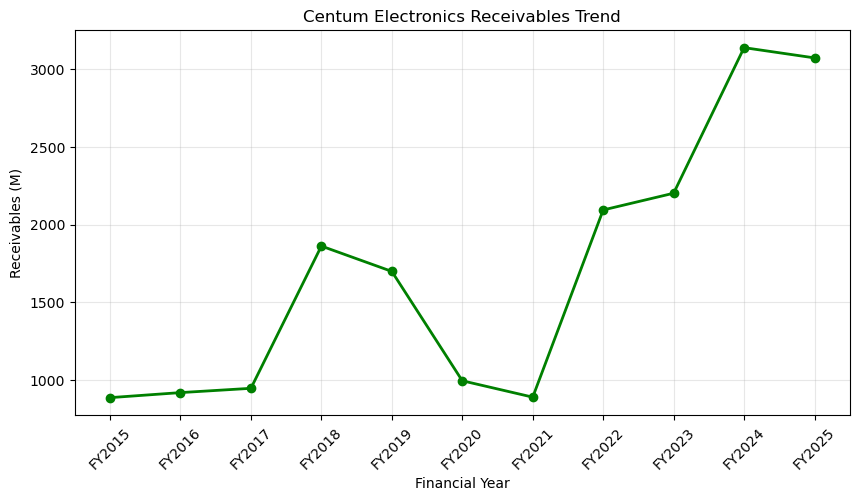

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Receivables(M)"],
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Centum Electronics Receivables Trend")
plt.xlabel("Financial Year")
plt.ylabel("Receivables (M)")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.show()

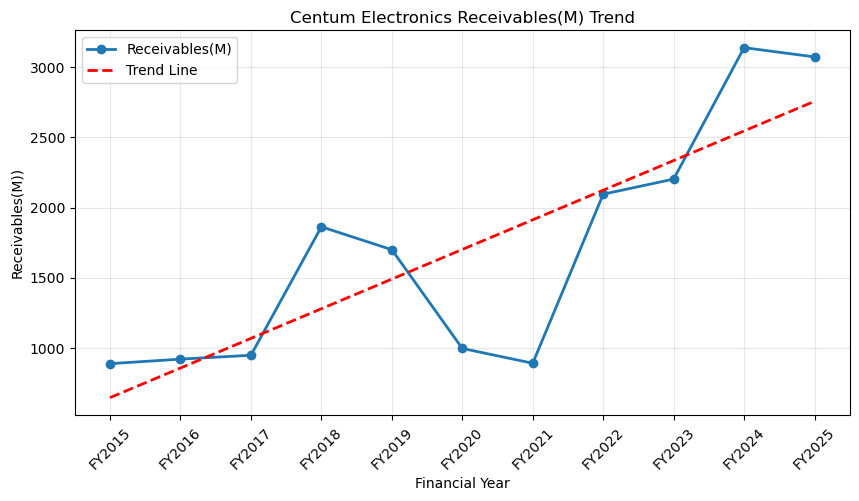

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# Receivables(M) trend
plt.plot(
    centum["Finacial Year"],
    centum["Receivables(M)"],
    marker="o",
    linewidth=2,
    label="Receivables(M)"
)

# Create trend line
x = np.arange(len(centum))
y = centum["Receivables(M)"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(
    centum["Finacial Year"],
    p(x),
    linestyle="--",
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Centum Electronics Receivables(M) Trend")
plt.xlabel("Financial Year")
plt.ylabel("Receivables(M))")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [28]:
slope = z[0]

r2 = np.corrcoef(y, p(x))[0,1]**2

print("Slope :", round(slope,2))
print("R²    :", round(r2,4))

Slope : 211.13
R²    : 0.6648


### 1.5.1 Receivables as a Percentage of Revenue

In [29]:
# Receivables as % of Revenue

centum["Receivables_to_Revenue_%"] = (
    centum["Receivables(M)"] / centum["Revenue(M)"]
) * 100

centum[
    [
        "Finacial Year",
        "Receivables(M)",
        "Revenue(M)",
        "Receivables_to_Revenue_%"
    ]
].round(2)

,Finacial Year,Receivables(M),Revenue(M),Receivables_to_Revenue_%
0,FY2015,887.56,3316.69,26.76
1,FY2016,919.99,3872.53,23.76
2,FY2017,947.57,3587.08,26.42
3,FY2018,1862.66,5058.28,36.82
4,FY2019,1699.65,4823.78,35.23
5,FY2020,996.16,4245.27,23.47
6,FY2021,890.67,3480.11,25.59
7,FY2022,2094.87,5005.54,41.85
8,FY2023,2202.63,6327.98,34.81
9,FY2024,3139.10,7498.38,41.86


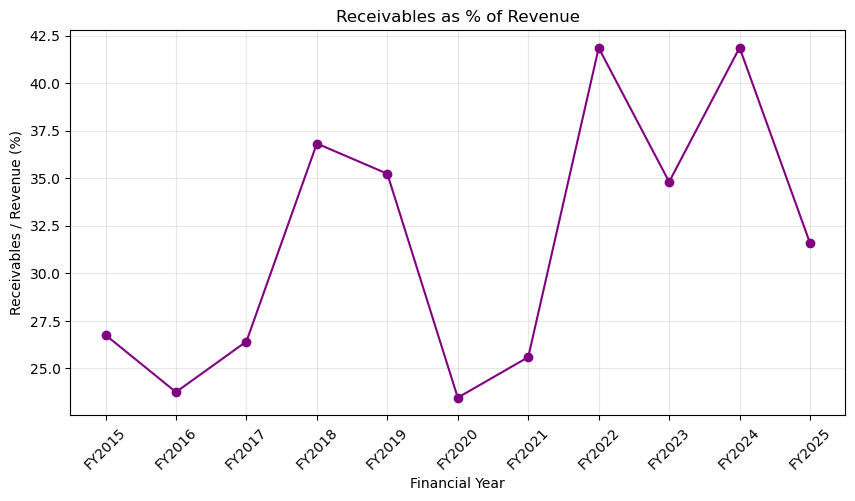

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Receivables_to_Revenue_%"],
    marker="o",
    color="purple"
)

plt.title("Receivables as % of Revenue")
plt.xlabel("Financial Year")
plt.ylabel("Receivables / Revenue (%)")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## 1.6 Payables Analysis

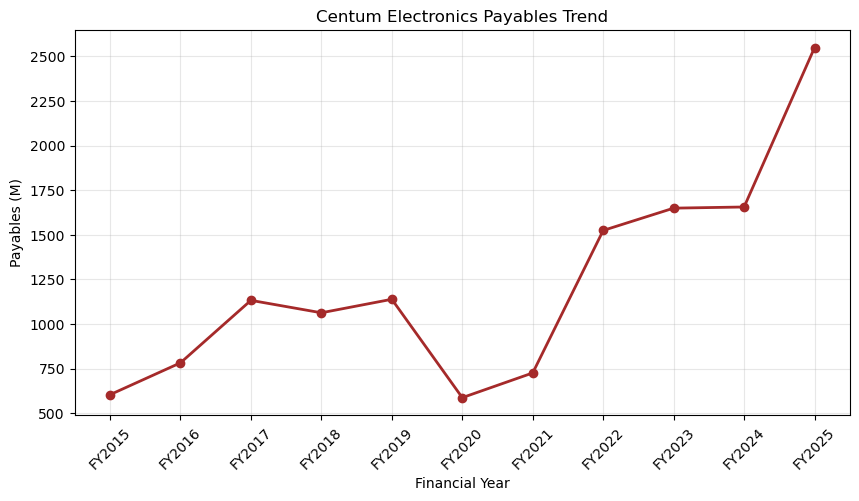

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Payables(M)"],
    marker="o",
    linewidth=2,
    color="brown"
)

plt.title("Centum Electronics Payables Trend")
plt.xlabel("Financial Year")
plt.ylabel("Payables (M)")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.show()

### 1.6.1 Payables as a Percentage of COGS

In [32]:
# Payables as % of COGS

centum["Payables_to_COGS_%"] = (
    centum["Payables(M)"] / centum["COGS(M)"]
) * 100

centum[
    [
        "Finacial Year",
        "Payables(M)",
        "COGS(M)",
        "Payables_to_COGS_%"
    ]
].round(2)

,Finacial Year,Payables(M),COGS(M),Payables_to_COGS_%
0,FY2015,604.29,2113.70,28.59
1,FY2016,782.86,2464.62,31.76
2,FY2017,1133.03,2536.08,44.68
3,FY2018,1063.35,3135.19,33.92
4,FY2019,1139.05,2803.51,40.63
5,FY2020,587.77,2526.49,23.26
6,FY2021,726.23,2032.75,35.73
7,FY2022,1524.85,3156.10,48.31
8,FY2023,1649.84,4034.91,40.89
9,FY2024,1656.30,4947.97,33.47


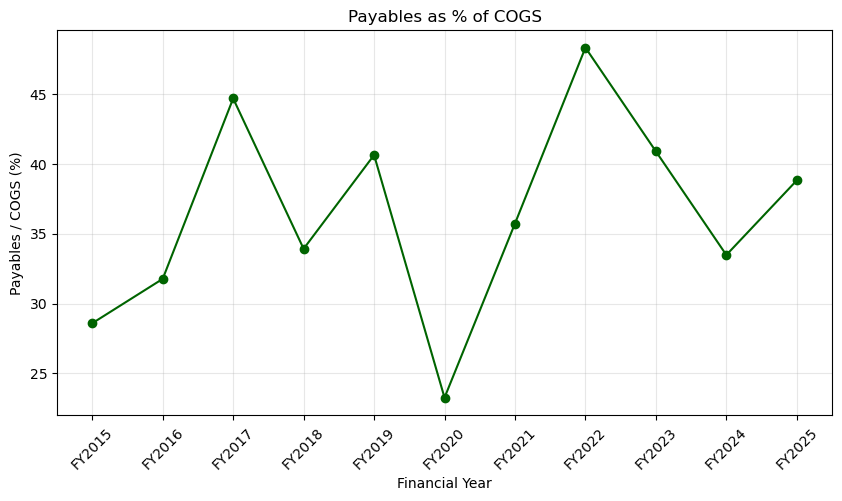

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["Payables_to_COGS_%"],
    marker="o",
    color="darkgreen"
)

plt.title("Payables as % of COGS")
plt.xlabel("Financial Year")
plt.ylabel("Payables / COGS (%)")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## 1.7 Days Sales Outstanding (DSO) Analysis

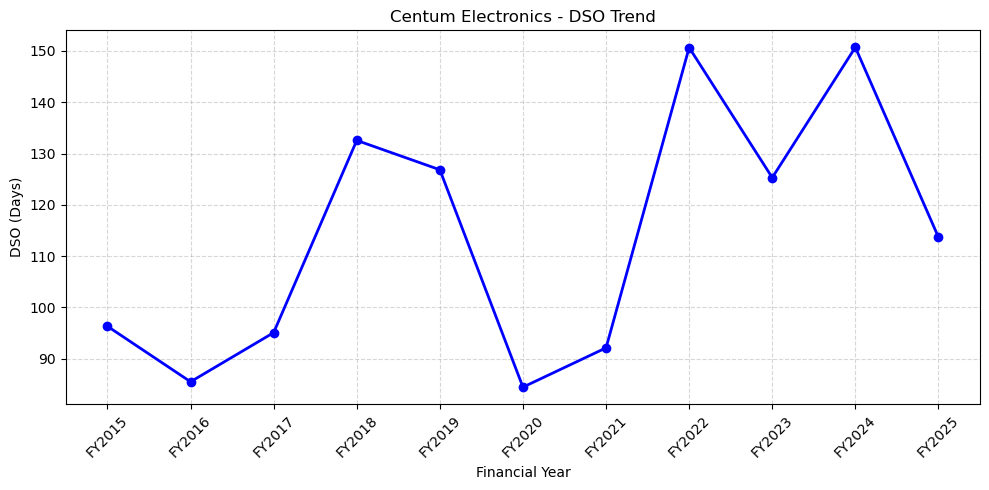

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["DSO(Days)"],
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title("Centum Electronics - DSO Trend")
plt.xlabel("Financial Year")
plt.ylabel("DSO (Days)")

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

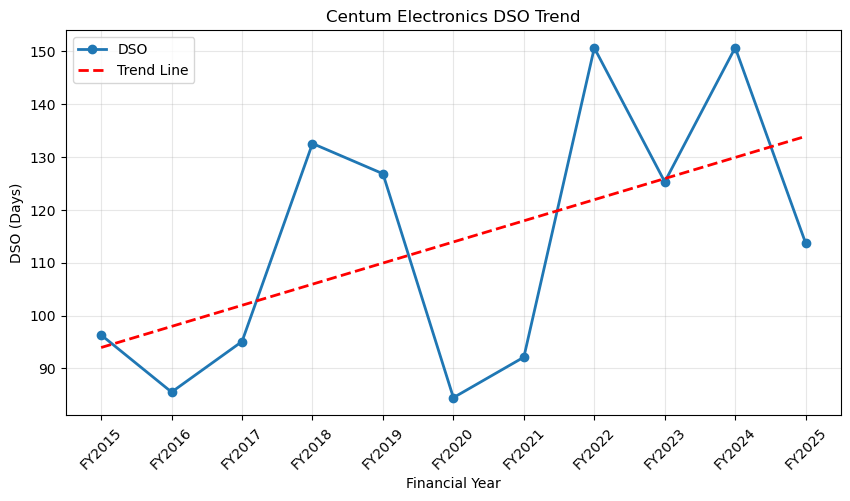

Slope     : 4.0
Intercept : 93.96
R²        : 0.2853


In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# DSO trend
plt.plot(
    centum["Finacial Year"],
    centum["DSO(Days)"],
    marker="o",
    linewidth=2,
    label="DSO"
)

# Create trend line
x = np.arange(len(centum))
y = centum["DSO(Days)"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(
    centum["Finacial Year"],
    p(x),
    linestyle="--",
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Centum Electronics DSO Trend")
plt.xlabel("Financial Year")
plt.ylabel("DSO (Days)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.show()

# Slope
slope = z[0]
intercept = z[1]

r2 = np.corrcoef(y, p(x))[0,1]**2

print("Slope     :", round(slope,2))
print("Intercept :", round(intercept,2))
print("R²        :", round(r2,4))

# R²
#r2 = np.corrcoef(y, p(x))[0,1]**2#

#print("Slope :", round(slope,2))#
#print("R²    :", round(r2,4))#

## 1.8 Days Inventory Outstanding (DIO) Analysis

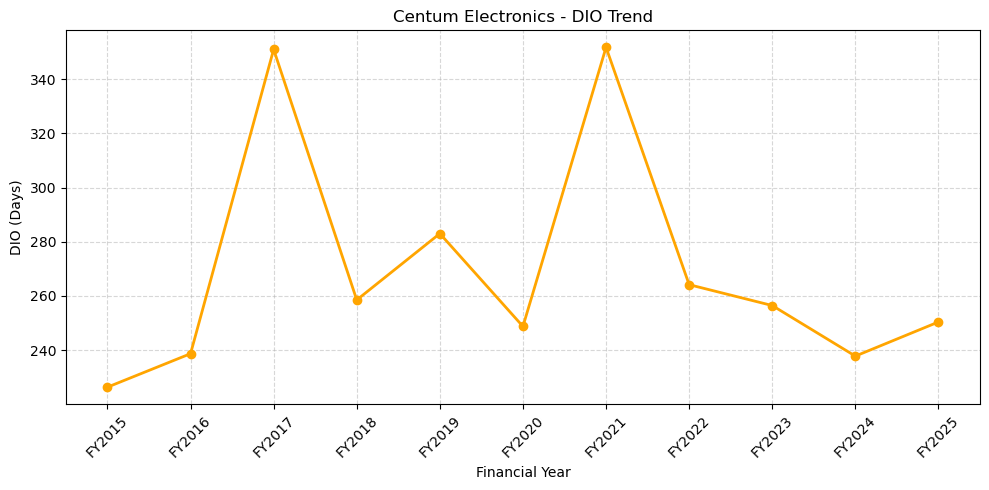

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["DIO(Days)"],
    marker='o',
    linewidth=2,
    color='orange'
)

plt.title("Centum Electronics - DIO Trend")
plt.xlabel("Financial Year")
plt.ylabel("DIO (Days)")

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


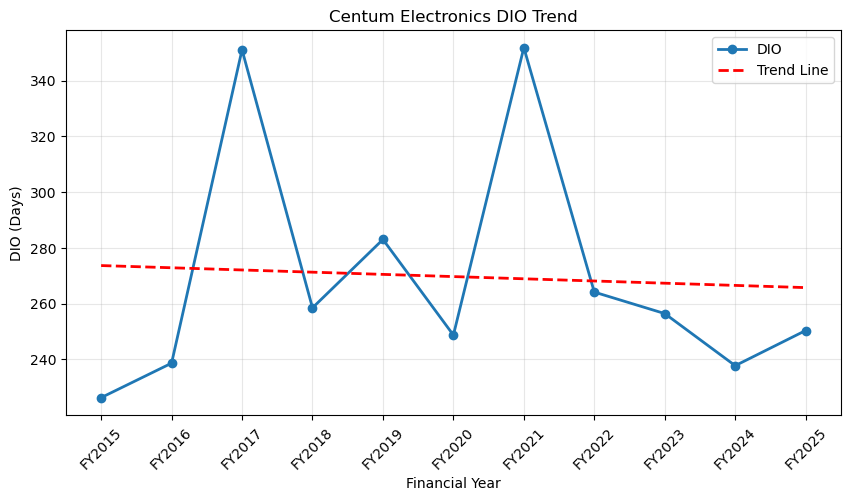

Slope     : -0.79
Intercept : 273.66
R²        : 0.0037


In [37]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# DIO trend
plt.plot(
    centum["Finacial Year"],
    centum["DIO(Days)"],
    marker="o",
    linewidth=2,
    label="DIO"
)

# Create trend line
x = np.arange(len(centum))
y = centum["DIO(Days)"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(
    centum["Finacial Year"],
    p(x),
    linestyle="--",
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Centum Electronics DIO Trend")
plt.xlabel("Financial Year")
plt.ylabel("DIO (Days)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.show()

# Metrics
slope = z[0]
intercept = z[1]
r2 = np.corrcoef(y, p(x))[0,1]**2

print("Slope     :", round(slope,2))
print("Intercept :", round(intercept,2))
print("R²        :", round(r2,4))

## 1.9 Days Payables Outstanding (DPO) Analysis

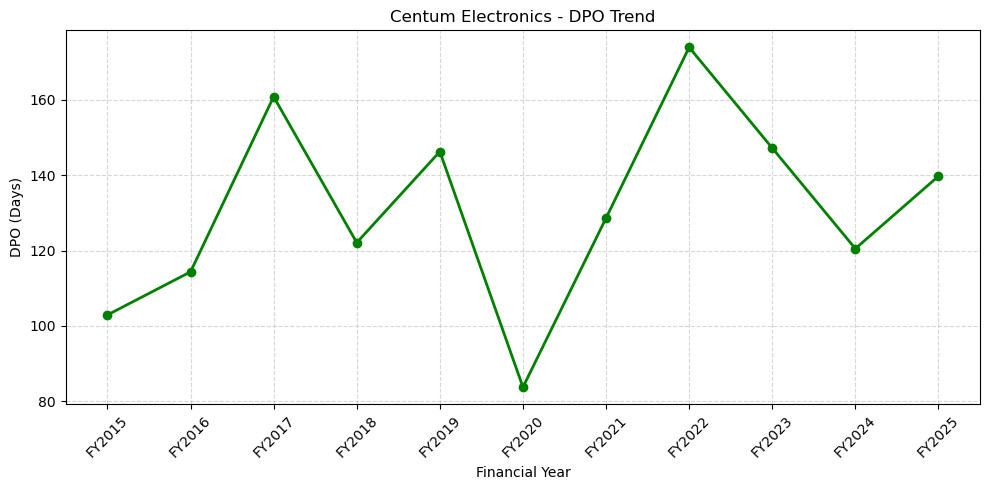

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["DPO(Days)"],
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Centum Electronics - DPO Trend")
plt.xlabel("Financial Year")
plt.ylabel("DPO (Days)")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

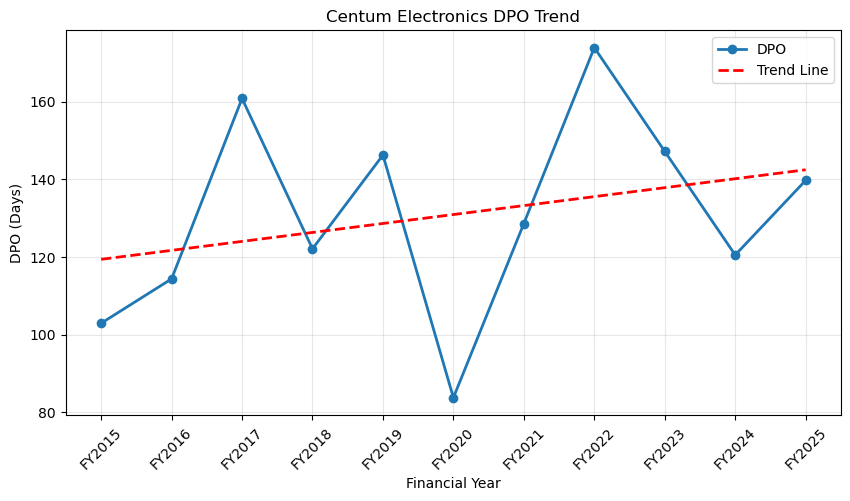

Slope     : 2.31
Intercept : 119.39
R²        : 0.0861


In [39]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# DPO trend
plt.plot(
    centum["Finacial Year"],
    centum["DPO(Days)"],
    marker="o",
    linewidth=2,
    label="DPO"
)

# Create trend line
x = np.arange(len(centum))
y = centum["DPO(Days)"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(
    centum["Finacial Year"],
    p(x),
    linestyle="--",
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Centum Electronics DPO Trend")
plt.xlabel("Financial Year")
plt.ylabel("DPO (Days)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.show()

# Metrics
slope = z[0]
intercept = z[1]

r2 = np.corrcoef(y, p(x))[0,1]**2

print("Slope     :", round(slope,2))
print("Intercept :", round(intercept,2))
print("R²        :", round(r2,4))

## 1.10 Cash Conversion Cycle (CCC) Analysis

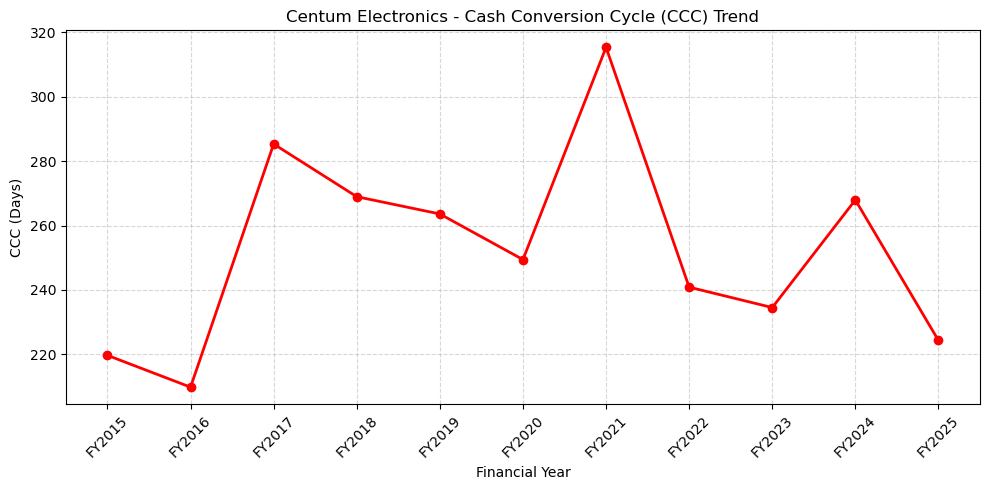

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["CCC(Days)"],
    marker="o",
    linewidth=2,
    color="red"
)

plt.title("Centum Electronics - Cash Conversion Cycle (CCC) Trend")
plt.xlabel("Financial Year")
plt.ylabel("CCC (Days)")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 1.11 Identification of Primary Working Capital Driver

In [41]:
# Average Working Capital Metrics

avg_dso = centum["DSO(Days)"].mean()
avg_dio = centum["DIO(Days)"].mean()
avg_dpo = centum["DPO(Days)"].mean()
avg_ccc = centum["CCC(Days)"].mean()

print(f"Average DSO : {avg_dso:.2f}")
print(f"Average DIO : {avg_dio:.2f}")
print(f"Average DPO : {avg_dpo:.2f}")
print(f"Average CCC : {avg_ccc:.2f}")

Average DSO : 113.94
Average DIO : 269.70
Average DPO : 130.93
Average CCC : 252.72


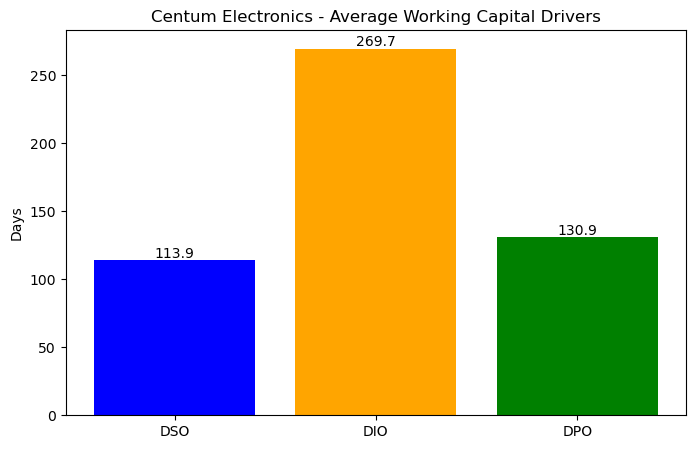

In [42]:
import matplotlib.pyplot as plt

avg_dso = centum["DSO(Days)"].mean()
avg_dio = centum["DIO(Days)"].mean()
avg_dpo = centum["DPO(Days)"].mean()

plt.figure(figsize=(8,5))

plt.bar(
    ["DSO", "DIO", "DPO"],
    [avg_dso, avg_dio, avg_dpo],
    color=["blue", "orange", "green"]
)

plt.title("Centum Electronics - Average Working Capital Drivers")
plt.ylabel("Days")

for i, v in enumerate([avg_dso, avg_dio, avg_dpo]):
    plt.text(i, v + 2, f"{v:.1f}", ha="center")

plt.show()

In [43]:
corr_matrix = centum[
    ["DSO(Days)", "DIO(Days)", "DPO(Days)", "CCC(Days)"]
].corr()

print(corr_matrix.round(2))

           DSO(Days)  DIO(Days)  DPO(Days)  CCC(Days)
DSO(Days)       1.00      -0.25       0.50       0.04
DIO(Days)      -0.25       1.00       0.44       0.81
DPO(Days)       0.50       0.44       1.00       0.18
CCC(Days)       0.04       0.81       0.18       1.00


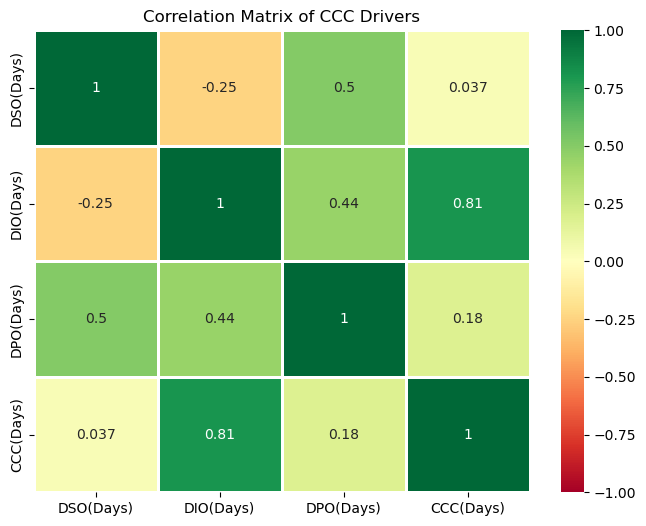

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = centum[
    ["DSO(Days)", "DIO(Days)", "DPO(Days)", "CCC(Days)"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    linewidths=1
)

plt.title("Correlation Matrix of CCC Drivers")

plt.show()

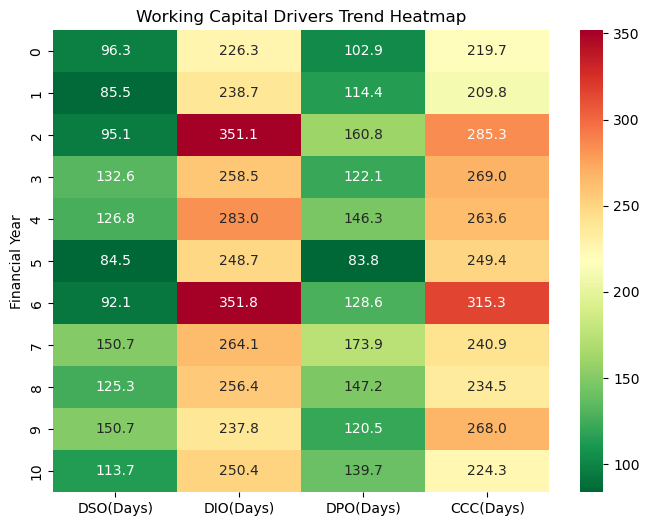

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = centum[
    ["DSO(Days)", "DIO(Days)", "DPO(Days)", "CCC(Days)"]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r"
)

plt.title("Working Capital Drivers Trend Heatmap")

plt.ylabel("Financial Year")

plt.show()

## 1.11 Key Historical Findings

In [46]:
chapter1_findings = pd.DataFrame({
    "Area": [
        "Revenue",
        "Inventory",
        "Receivables",
        "Payables",
        "DSO",
        "DIO",
        "DPO",
        "CCC"
    ],
    "Observation": [
        "Revenue increased from 3,316.69 million in FY2016 to 9,730.56 million in FY2026.",
        "Inventory increased from 1,328.60 million to 4,567.76 million during the study period.",
        "Receivables increased from 887.56 million to 3,073.09 million, reflecting growth in credit sales and working capital requirements.",
        "Payables increased from 604.29 million to 2,549.37 million, indicating improved supplier financing support.",
        "DSO remained volatile throughout the study period, ranging between approximately 85 and 151 days.",
        "DIO was the highest working capital metric across most years and averaged 269.70 days.",
        "DPO showed an improving but volatile trend, averaging 130.93 days.",
        "CCC remained volatile, ranging between approximately 210 and 315 days, with an average of 252.72 days."
    ]
})

display(chapter1_findings)

,Area,Observation
0,Revenue,"Revenue increased from 3,316.69 million in FY2..."
1,Inventory,"Inventory increased from 1,328.60 million to 4..."
2,Receivables,Receivables increased from 887.56 million to 3...
3,Payables,"Payables increased from 604.29 million to 2,54..."
4,DSO,DSO remained volatile throughout the study per...
5,DIO,DIO was the highest working capital metric acr...
6,DPO,"DPO showed an improving but volatile trend, av..."
7,CCC,"CCC remained volatile, ranging between approxi..."


In [47]:
chapter1_findings = pd.DataFrame({
    "Area": [
        "Revenue",
        "Inventory",
        "Receivables",
        "Payables",
        "DSO",
        "DIO",
        "DPO",
        "CCC"
    ],

    "Observation": [
        "Revenue increased from 3,316.69 million to 9,730.56 million.",
        "Inventory increased from 1,328.60 million to 4,567.76 million.",
        "Receivables increased from 887.56 million to 3,073.09 million.",
        "Payables increased from 604.29 million to 2,549.37 million.",
        "DSO remained volatile during the study period.",
        "DIO was the highest working capital metric across most years.",
        "DPO showed an improving but volatile trend.",
        "CCC remained volatile, ranging between approximately 210 and 315 days."
    ]
})

chapter1_findings

,Area,Observation
0,Revenue,"Revenue increased from 3,316.69 million to 9,7..."
1,Inventory,"Inventory increased from 1,328.60 million to 4..."
2,Receivables,Receivables increased from 887.56 million to 3...
3,Payables,"Payables increased from 604.29 million to 2,54..."
4,DSO,DSO remained volatile during the study period.
5,DIO,DIO was the highest working capital metric acr...
6,DPO,DPO showed an improving but volatile trend.
7,CCC,"CCC remained volatile, ranging between approxi..."


Then write these 5 findings in your dissertation
Finding 1
Revenue increased significantly during the study period, indicating growth in business operations.
Finding 2
Inventory grew substantially over time and remained a significant component of working capital.
Finding 3
Receivables increased faster than revenue in certain periods, indicating fluctuations in collection efficiency.
Finding 4
Payables increased over time, reflecting greater supplier financing support.
Finding 5 (Most Important)
Average DIO (269.70 days) was substantially higher than average DSO (113.94 days) and DPO (130.93 days), indicating that inventory is the dominant contributor to Centum's cash conversion cycle

Revenue increased from 3,316.69 million in FY2016 to 9,730.56 million in FY2026.
Inventory increased from 1,328.60 million to 4,567.76 million over the study period.
Receivables increased from 887.56 million to 3,073.09 million.
Payables increased from 604.29 million to 2,549.37 million.
DSO remained volatile, ranging approximately between 85 and 151 days.
DIO remained the largest working capital component with an average of 269.70 days.
DPO showed an increasing but volatile trend, with an average of 130.93 days.
CCC averaged 252.72 days and remained volatile throughout the study period.
Based on the average working capital metrics, Inventory (DIO) is the primary contributor to Centum's working capital requirement

SES DSO DIO DPO

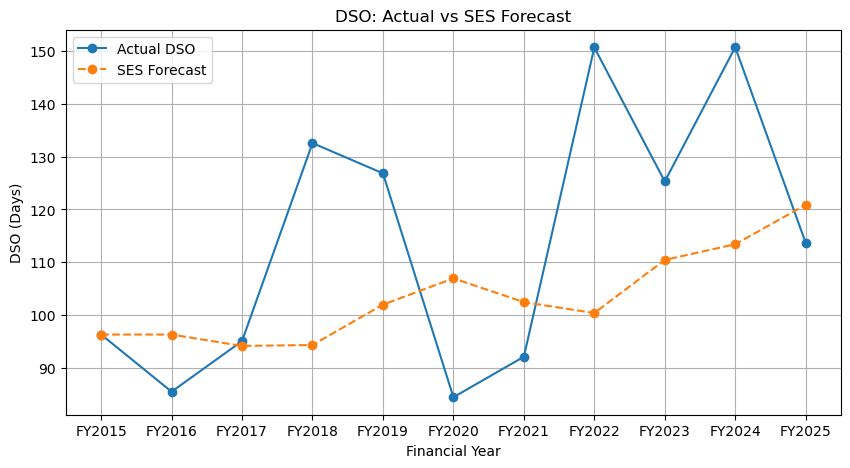

In [48]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
dso_ses = SimpleExpSmoothing(
    centum["DSO(Days)"]
).fit(
    smoothing_level=0.2,
    optimized=False
)
centum["DSO SES Forecast"] = dso_ses.fittedvalues
plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["DSO(Days)"],
    marker="o",
    label="Actual DSO"
)

plt.plot(
    centum["Finacial Year"],
    centum["DSO SES Forecast"],
    marker="o",
    linestyle="--",
    label="SES Forecast"
)

plt.title("DSO: Actual vs SES Forecast")
plt.xlabel("Financial Year")
plt.ylabel("DSO (Days)")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
future_dso = dso_ses.forecast(3)

print(future_dso)

11    119.445182
12    119.445182
13    119.445182
dtype: float64


In [50]:
dso_forecast_table = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],
    "Forecast DSO (Days)": np.round(future_dso, 2)
})

print(dso_forecast_table)

   Financial Year  Forecast DSO (Days)
11        FY2026F               119.45
12        FY2027F               119.45
13        FY2028F               119.45


In [51]:
import numpy as np

error = centum["DSO(Days)"] - centum["DSO SES Forecast"]

mae = np.mean(np.abs(error))

mape = np.mean(
    np.abs(error / centum["DSO(Days)"])
) * 100

rmse = np.sqrt(
    np.mean(error**2)
)

print("Alpha:", 0.2)
print("MAE :", round(mae,2))
print("MAPE:", round(mape,2))
print("RMSE:", round(rmse,2))

Alpha: 0.2
MAE : 19.75
MAPE: 16.01
RMSE: 25.22


In [52]:
# DSO SES
dso_ses_mae = mae
dso_ses_mape = mape
dso_ses_rmse = rmse

dio

In [53]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

dio_ses = SimpleExpSmoothing(
    centum["DIO(Days)"]
).fit(
    smoothing_level=0.2,
    optimized=False
)

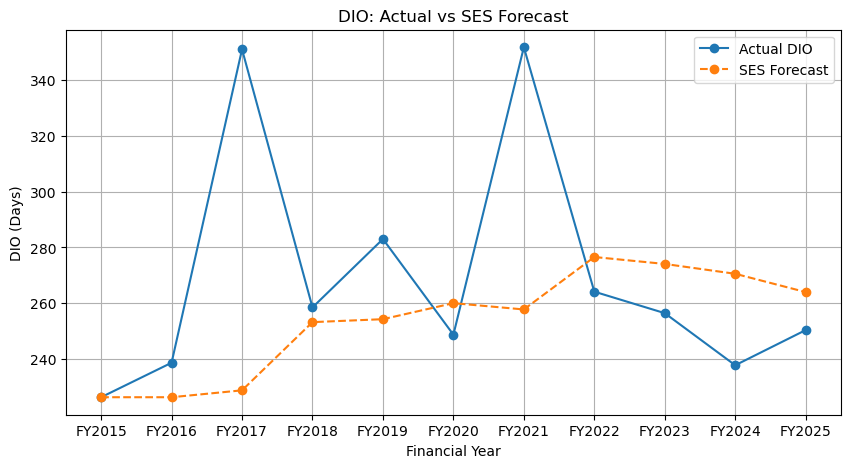

In [54]:
centum["DIO SES Forecast"] = dio_ses.fittedvalues
plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["DIO(Days)"],
    marker="o",
    label="Actual DIO"
)

plt.plot(
    centum["Finacial Year"],
    centum["DIO SES Forecast"],
    marker="o",
    linestyle="--",
    label="SES Forecast"
)

plt.title("DIO: Actual vs SES Forecast")
plt.xlabel("Financial Year")
plt.ylabel("DIO (Days)")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
future_dio = dio_ses.forecast(3)

print(future_dio)

11    261.26999
12    261.26999
13    261.26999
dtype: float64


In [56]:
future_dio = dio_ses.forecast(3)
dio_forecast_table = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],
    "Forecast DIO (Days)": np.round(future_dio, 2)
})

print(dio_forecast_table)

   Financial Year  Forecast DIO (Days)
11        FY2026F               261.27
12        FY2027F               261.27
13        FY2028F               261.27


In [57]:
import numpy as np

error = centum["DIO(Days)"] - centum["DIO SES Forecast"]

mae = np.mean(np.abs(error))

mape = np.mean(
    np.abs(error / centum["DIO(Days)"])
) * 100

rmse = np.sqrt(
    np.mean(error**2)
)

print("Alpha:", 0.2)
print("MAE :", round(mae,2))
print("MAPE:", round(mape,2))
print("RMSE:", round(rmse,2))

Alpha: 0.2
MAE : 31.87
MAPE: 10.39
RMSE: 49.24


In [58]:
# DIO SES
dio_ses_mae = mae
dio_ses_mape = mape
dio_ses_rmse = rmse

DPO

In [59]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

dpo_ses = SimpleExpSmoothing(
    centum["DPO(Days)"]
).fit(
    smoothing_level=0.2,
    optimized=False
)

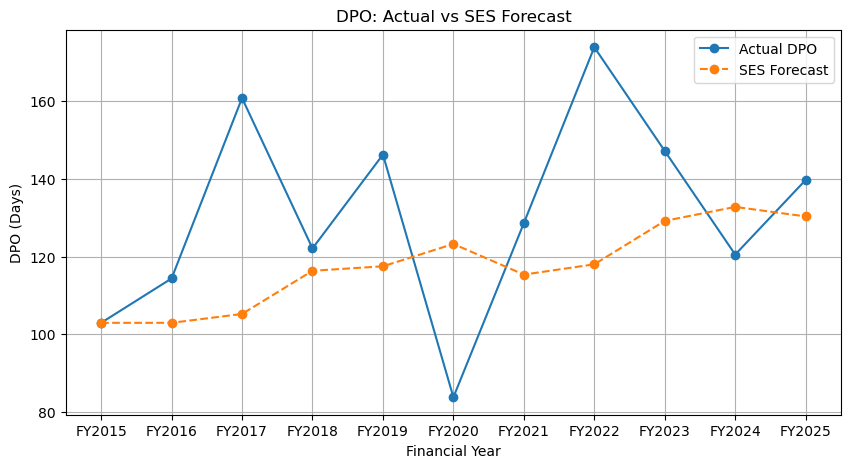

In [60]:
centum["DPO SES Forecast"] = dpo_ses.fittedvalues

plt.figure(figsize=(10,5))

plt.plot(
    centum["Finacial Year"],
    centum["DPO(Days)"],
    marker="o",
    label="Actual DPO"
)

plt.plot(
    centum["Finacial Year"],
    centum["DPO SES Forecast"],
    marker="o",
    linestyle="--",
    label="SES Forecast"
)

plt.title("DPO: Actual vs SES Forecast")
plt.xlabel("Financial Year")
plt.ylabel("DPO (Days)")
plt.legend()
plt.grid(True)

plt.show()

In [61]:
future_dpo = dpo_ses.forecast(3)

print(future_dpo)

11    132.212376
12    132.212376
13    132.212376
dtype: float64


In [62]:
future_dpo = dpo_ses.forecast(3)
dpo_forecast_table = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],
    "Forecast DPO (Days)": np.round(future_dpo, 2)
})

print(dpo_forecast_table)

   Financial Year  Forecast DPO (Days)
11        FY2026F               132.21
12        FY2027F               132.21
13        FY2028F               132.21


In [63]:
import numpy as np

error = centum["DPO(Days)"] - centum["DPO SES Forecast"]

mae = np.mean(np.abs(error))

mape = np.mean(
    np.abs(error / centum["DPO(Days)"])
) * 100

rmse = np.sqrt(
    np.mean(error**2)
)

print("Alpha:", 0.2)
print("MAE :", round(mae,2))
print("MAPE:", round(mape,2))
print("RMSE:", round(rmse,2))

Alpha: 0.2
MAE : 22.73
MAPE: 17.07
RMSE: 29.41


In [64]:
# DPO SES
dpo_ses_mae = mae
dpo_ses_mape = mape
dpo_ses_rmse = rmse

DSO - MA(3)

Create the moving average model:

In [65]:
centum["DSO MA3 Forecast"] = (
    centum["DSO(Days)"]
    .rolling(window=3)
    .mean()
    .shift(1)
)

Metrics ma dso 

In [66]:
error = (
    centum["DSO(Days)"] -
    centum["DSO MA3 Forecast"]
).dropna()

actual = centum.loc[
    error.index,
    "DSO(Days)"
]

mae = np.mean(np.abs(error))

mape = np.mean(
    np.abs(error / actual)
) * 100

rmse = np.sqrt(
    np.mean(error**2)
)

print("MAE :", round(mae,2))
print("MAPE:", round(mape,2))
print("RMSE:", round(rmse,2))

MAE : 30.14
MAPE: 25.23
RMSE: 31.78


In [67]:
# DSO MA3
dso_ma3_mae = mae
dso_ma3_mape = mape
dso_ma3_rmse = rmse


MA3 DSO FUTURE FORECAST

In [68]:
centum[["Finacial Year","DSO(Days)","DSO MA3 Forecast"]]

,Finacial Year,DSO(Days),DSO MA3 Forecast
0,FY2015,96.337414,NaN
1,FY2016,85.525014,NaN
2,FY2017,95.098424,NaN
3,FY2018,132.566462,92.320284
4,FY2019,126.845337,104.396633
5,FY2020,84.474627,118.170074
6,FY2021,92.135364,114.628809
7,FY2022,150.663705,101.151776
8,FY2023,125.308045,109.091232
9,FY2024,150.709353,122.702371


In [69]:
fy2026 = centum["DSO(Days)"].tail(3).mean()

fy2027 = (
    centum["DSO(Days)"].iloc[-2] +
    centum["DSO(Days)"].iloc[-1] +
    fy2026
) / 3

fy2028 = (
    centum["DSO(Days)"].iloc[-1] +
    fy2026 +
    fy2027
) / 3

In [70]:
dso_ma3_forecast = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],
    "Forecast DSO (Days)": [
        round(fy2026, 2),
        round(fy2027, 2),
        round(fy2028, 2)
    ]
})

print(dso_ma3_forecast)

  Financial Year  Forecast DSO (Days)
0        FY2026F               129.90
1        FY2027F               131.44
2        FY2028F               125.01


DIO - MA(3)

Create the moving average model:

In [71]:
centum["DIO MA3 Forecast"] = (
    centum["DIO(Days)"]
    .rolling(window=3)
    .mean()
    .shift(1)
)

Metrics ma dso 

In [72]:
error = (
    centum["DIO(Days)"] -
    centum["DIO MA3 Forecast"]
).dropna()

actual = centum.loc[
    error.index,
    "DIO(Days)"
]

mae = np.mean(np.abs(error))

mape = np.mean(
    np.abs(error / actual)
) * 100

rmse = np.sqrt(
    np.mean(error**2)
)

print("MAE :", round(mae,2))
print("MAPE:", round(mape,2))
print("RMSE:", round(rmse,2))

MAE : 33.58
MAPE: 12.16
RMSE: 43.5


In [73]:
# DIO MA3
dio_ma3_mae = mae
dio_ma3_mape = mape
dio_ma3_rmse = rmse

MA3 DIO FUTURE FORECAST

In [74]:
centum[["Finacial Year","DIO(Days)","DIO MA3 Forecast"]]

,Finacial Year,DIO(Days),DIO MA3 Forecast
0,FY2015,226.284235,NaN
1,FY2016,238.651703,NaN
2,FY2017,351.062331,NaN
3,FY2018,258.499013,271.999423
4,FY2019,283.024352,282.737682
5,FY2020,248.715174,297.528565
6,FY2021,351.821523,263.412846
7,FY2022,264.141060,294.520349
8,FY2023,256.436352,288.225919
9,FY2024,237.751320,290.799645


In [75]:
fy2026 = centum["DIO(Days)"].tail(3).mean()

fy2027 = (
    centum["DIO(Days)"].iloc[-2] +
    centum["DIO(Days)"].iloc[-1] +
    fy2026
) / 3

fy2028 = (
    centum["DIO(Days)"].iloc[-1] +
    fy2026 +
    fy2027
) / 3

In [76]:
dio_ma3_forecast = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],
    "Forecast DIO (Days)": [
        round(fy2026, 2),
        round(fy2027, 2),
        round(fy2028, 2)
    ]
})

print(dio_ma3_forecast)

  Financial Year  Forecast DIO (Days)
0        FY2026F               248.18
1        FY2027F               245.43
2        FY2028F               247.99


DPO - MA(3)

Create the moving average model:

In [77]:
centum["DPO MA3 Forecast"] = (
    centum["DPO(Days)"]
    .rolling(window=3)
    .mean()
    .shift(1)
)

Metric ma DPO

In [78]:
error = (
    centum["DPO(Days)"] -
    centum["DPO MA3 Forecast"]
).dropna()

actual = centum.loc[
    error.index,
    "DPO(Days)"
]

mae = np.mean(np.abs(error))

mape = np.mean(
    np.abs(error / actual)
) * 100

rmse = np.sqrt(
    np.mean(error**2)
)

print("MAE :", round(mae,2))
print("MAPE:", round(mape,2))
print("RMSE:", round(rmse,2))

MAE : 24.76
MAPE: 20.72
RMSE: 31.76


In [79]:
# DPO MA3
dpo_ma3_mae = mae
dpo_ma3_mape = mape
dpo_ma3_rmse = rmse

MA3 DPO FUTURE FORECAST

In [80]:
centum[["Finacial Year","DPO(Days)","DPO MA3 Forecast"]]

,Finacial Year,DPO(Days),DPO MA3 Forecast
0,FY2015,102.920696,NaN
1,FY2016,114.350077,NaN
2,FY2017,160.834610,NaN
3,FY2018,122.099662,126.035127
4,FY2019,146.265931,132.428116
5,FY2020,83.751450,143.066734
6,FY2021,128.615324,117.372348
7,FY2022,173.931751,119.544235
8,FY2023,147.200904,128.766175
9,FY2024,120.507602,149.915993


In [81]:
fy2026 = centum["DPO(Days)"].tail(3).mean()

fy2027 = (
    centum["DPO(Days)"].iloc[-2] +
    centum["DPO(Days)"].iloc[-1] +
    fy2026
) / 3

fy2028 = (
    centum["DPO(Days)"].iloc[-1] +
    fy2026 +
    fy2027
) / 3

In [82]:
dpo_ma3_forecast = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],
    "Forecast DPO (Days)": [
        round(fy2026, 2),
        round(fy2027, 2),
        round(fy2028, 2)
    ]
})

print(dpo_ma3_forecast)

  Financial Year  Forecast DPO (Days)
0        FY2026F               135.81
1        FY2027F               132.02
2        FY2028F               135.86


Metrics sUMMARY OF DSO DIO DPO SES MA3 models

In [83]:
summary_metrics = pd.DataFrame({
    "Driver": [
        "DSO","DSO",
        "DIO","DIO",
        "DPO","DPO"
    ],
    "Model": [
        "SES","MA(3)",
        "SES","MA(3)",
        "SES","MA(3)"
    ],
    "MAE": [
        dso_ses_mae,
        dso_ma3_mae,
        dio_ses_mae,
        dio_ma3_mae,
        dpo_ses_mae,
        dpo_ma3_mae
    ],
    "MAPE (%)": [
        dso_ses_mape,
        dso_ma3_mape,
        dio_ses_mape,
        dio_ma3_mape,
        dpo_ses_mape,
        dpo_ma3_mape
    ],
    "RMSE": [
        dso_ses_rmse,
        dso_ma3_rmse,
        dio_ses_rmse,
        dio_ma3_rmse,
        dpo_ses_rmse,
        dpo_ma3_rmse
    ]
})

summary_metrics = summary_metrics.round(2)

print(summary_metrics)

  Driver  Model    MAE  MAPE (%)   RMSE
0    DSO    SES  19.75     16.01  25.22
1    DSO  MA(3)  30.14     25.23  31.78
2    DIO    SES  31.87     10.39  49.24
3    DIO  MA(3)  33.58     12.16  43.50
4    DPO    SES  22.73     17.07  29.41
5    DPO  MA(3)  24.76     20.72  31.76


Model Selction Based on the MAPE

In [84]:
best_models = (
    summary_metrics
    .sort_values(
        ["Driver", "MAPE (%)", "MAE", "RMSE" ]
    )
    .groupby("Driver")
    .first()
    .reset_index()
)

print(best_models)

  Driver Model    MAE  MAPE (%)   RMSE
0    DIO   SES  31.87     10.39  49.24
1    DPO   SES  22.73     17.07  29.41
2    DSO   SES  19.75     16.01  25.22


Forecasted Revenue dso dio dpo ccc

In [85]:
final_forecast = pd.DataFrame({
    "Financial Year": ["FY2026F", "FY2027F", "FY2028F"],

    # Revenue - Linear Trend
    "Revenue (M)": np.round(
        [fy26_forecast, fy27_forecast, fy28_forecast],
        2
    ),

    # DSO - SES
    "DSO (Days)": np.round(
        future_dso,
        2
    ),

    # DIO - SES
    "DIO (Days)": np.round(
        future_dio,
        2
    ),

    # DPO - SES
    "DPO (Days)": np.round(
        future_dpo,
        2
    )
})

final_forecast["CCC (Days)"] = (
    final_forecast["DSO (Days)"]
    + final_forecast["DIO (Days)"]
    - final_forecast["DPO (Days)"]
)

print(final_forecast.round(2))

   Financial Year  Revenue (M)  DSO (Days)  DIO (Days)  DPO (Days)  CCC (Days)
11        FY2026F      8086.73      119.45      261.27      132.21      248.51
12        FY2027F      8571.69      119.45      261.27      132.21      248.51
13        FY2028F      9056.66      119.45      261.27      132.21      248.51


Peer Benchmarking

In [86]:
import pandas as pd

# Read Excel File
file_path = r"CCC_DATA.xlsx"

all_sheets = pd.read_excel(
    file_path,
    sheet_name=None
)

# Create Benchmark Dataset
benchmark = []

for company, df in all_sheets.items():

    avg_dso = df["DSO(Days)"].mean()

    avg_dio = df["DIO(Days)"].mean()

    avg_dpo = df["DPO(Days)"].mean()

    avg_ccc = avg_dso + avg_dio - avg_dpo

    benchmark.append({
        "Company": company,
        "Avg DSO": avg_dso,
        "Avg DIO": avg_dio,
        "Avg DPO": avg_dpo,
        "Avg CCC": avg_ccc
    })

# Create DataFrame
benchmark_df = pd.DataFrame(benchmark)

# Round Values
benchmark_df = benchmark_df.round(2)

# Display Output
print(benchmark_df.to_string(index=False))

             Company  Avg DSO  Avg DIO  Avg DPO  Avg CCC
              Centum   113.94   269.70   130.93   252.72
               Astra   184.33   287.35    49.60   422.08
        Datapatterns   311.33   678.60   121.01   868.91
  Kaynes Technolgies    91.19   177.83   119.49   149.54
Apollo Micro Sysyems   202.14   479.86   192.80   489.20


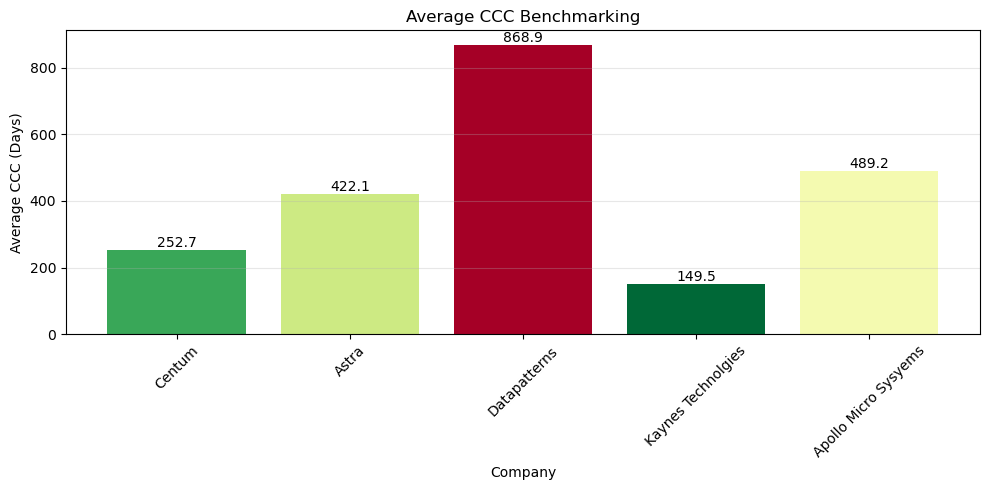

In [87]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Create color gradient based on CCC
norm = mcolors.Normalize(
    vmin=benchmark_df["Avg CCC"].min(),
    vmax=benchmark_df["Avg CCC"].max()
)

colors = cm.RdYlGn_r(norm(benchmark_df["Avg CCC"]))

plt.figure(figsize=(10,5))

bars = plt.bar(
    benchmark_df["Company"],
    benchmark_df["Avg CCC"],
    color=colors
)

plt.title("Average CCC Benchmarking")
plt.xlabel("Company")
plt.ylabel("Average CCC (Days)")
plt.xticks(rotation=45)

# Show value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [88]:
best_company = benchmark_df.loc[
    benchmark_df["Avg CCC"].idxmin()
]

print("Best Company :", best_company["Company"])
print("Avg CCC      :", round(best_company["Avg CCC"], 2))

Best Company : Kaynes Technolgies
Avg CCC      : 149.54


In [89]:
ccc_ranking = benchmark_df.sort_values(
    "Avg CCC",
    ascending=True
).reset_index(drop=True)

ccc_ranking["CCC Rank"] = range(
    1,
    len(ccc_ranking) + 1
)

ccc_ranking = ccc_ranking[
    [
        "CCC Rank",
        "Company",
        "Avg DSO",
        "Avg DIO",
        "Avg DPO",
        "Avg CCC"
    ]
]

print(ccc_ranking.to_string(index=False))

 CCC Rank              Company  Avg DSO  Avg DIO  Avg DPO  Avg CCC
        1   Kaynes Technolgies    91.19   177.83   119.49   149.54
        2               Centum   113.94   269.70   130.93   252.72
        3                Astra   184.33   287.35    49.60   422.08
        4 Apollo Micro Sysyems   202.14   479.86   192.80   489.20
        5         Datapatterns   311.33   678.60   121.01   868.91


In [90]:
# Best Company (Lowest Avg CCC)
best_company = benchmark_df.loc[
    benchmark_df["Avg CCC"].idxmin()
]

# Centum Row
centum_company = benchmark_df[
    benchmark_df["Company"] == "Centum"
].iloc[0]

# Gap Table
gap_table = pd.DataFrame({
    "Metric": ["DSO", "DIO", "DPO", "CCC"],
    
    "Best Company": [
        round(best_company["Avg DSO"], 2),
        round(best_company["Avg DIO"], 2),
        round(best_company["Avg DPO"], 2),
        round(best_company["Avg CCC"], 2)
    ],
    
    "Centum": [
        round(centum_company["Avg DSO"], 2),
        round(centum_company["Avg DIO"], 2),
        round(centum_company["Avg DPO"], 2),
        round(centum_company["Avg CCC"], 2)
    ]
})

gap_table["Gap"] = (
    gap_table["Centum"]
    - gap_table["Best Company"]
).round(2)

print("Benchmark Company :", best_company["Company"])
print()
print(gap_table.to_string(index=False))

Benchmark Company : Kaynes Technolgies

Metric  Best Company  Centum    Gap
   DSO         91.19  113.94  22.75
   DIO        177.83  269.70  91.87
   DPO        119.49  130.93  11.44
   CCC        149.54  252.72 103.18


In [91]:
# Best Benchmark Company
best_company = benchmark_df.loc[
    benchmark_df["Avg CCC"].idxmin()
]

# Centum
centum_company = benchmark_df[
    benchmark_df["Company"] == "Centum"
].iloc[0]

# Opportunity Ranking
opportunity_ranking = pd.DataFrame({
    "CCC Driver": ["DSO", "DIO", "DPO"],

    "Benchmark": [
        best_company["Avg DSO"],
        best_company["Avg DIO"],
        best_company["Avg DPO"]
    ],

    "Centum": [
        centum_company["Avg DSO"],
        centum_company["Avg DIO"],
        centum_company["Avg DPO"]
    ],

    "Opportunity (Days)": [
        centum_company["Avg DSO"] - best_company["Avg DSO"],
        centum_company["Avg DIO"] - best_company["Avg DIO"],
        best_company["Avg DPO"] - centum_company["Avg DPO"]
    ]
})

opportunity_ranking = opportunity_ranking.sort_values(
    "Opportunity (Days)",
    ascending=False
).reset_index(drop=True)

opportunity_ranking["Priority Rank"] = range(
    1,
    len(opportunity_ranking) + 1
)

opportunity_ranking = opportunity_ranking.round(2)

print(opportunity_ranking.to_string(index=False))

CCC Driver  Benchmark  Centum  Opportunity (Days)  Priority Rank
       DIO     177.83  269.70               91.87              1
       DSO      91.19  113.94               22.75              2
       DPO     119.49  130.93              -11.44              3


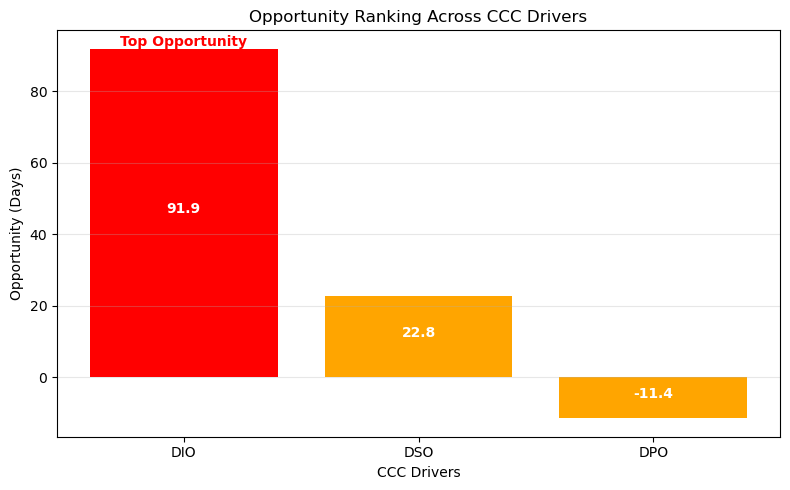

In [92]:
import matplotlib.pyplot as plt

# Colors: Top opportunity = red, others = orange
colors = ["red"] + ["orange"] * (len(opportunity_ranking) - 1)

plt.figure(figsize=(8,5))

bars = plt.bar(
    opportunity_ranking["CCC Driver"],
    opportunity_ranking["Opportunity (Days)"],
    color=colors
)

# Highlight top driver
top_bar = bars[0]

plt.text(
    top_bar.get_x() + top_bar.get_width()/2,
    top_bar.get_height(),
    "Top Opportunity",
    ha="center",
    va="bottom",
    fontweight="bold",
    color="red"
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f"{bar.get_height():.1f}",
        ha="center",
        color="white",
        fontweight="bold"
    )

plt.title("Opportunity Ranking Across CCC Drivers")
plt.xlabel("CCC Drivers")
plt.ylabel("Opportunity (Days)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

CCC Improvement Potential

In [93]:
best_company = benchmark_df.loc[
    benchmark_df["Avg CCC"].idxmin()
]

centum_company = benchmark_df[
    benchmark_df["Company"] == "Centum"
].iloc[0]

improvement_days = (
    centum_company["Avg CCC"]
    - best_company["Avg CCC"]
)

improvement_pct = (
    improvement_days
    / centum_company["Avg CCC"]
) * 100

print("Current CCC :", round(centum_company["Avg CCC"],2))
print("Benchmark CCC :", round(best_company["Avg CCC"],2))
print("Reduction Potential (Days) :", round(improvement_days,2))
print("Reduction Potential (%) :", round(improvement_pct,2))


Current CCC : 252.72
Benchmark CCC : 149.54
Reduction Potential (Days) : 103.18
Reduction Potential (%) : 40.83


Benchmark Positioning Table

In [94]:
positioning = pd.DataFrame({
    "Driver": ["DSO","DIO","DPO","CCC"],
    "Centum": [
        centum_company["Avg DSO"],
        centum_company["Avg DIO"],
        centum_company["Avg DPO"],
        centum_company["Avg CCC"]
    ],
    "Benchmark": [
        best_company["Avg DSO"],
        best_company["Avg DIO"],
        best_company["Avg DPO"],
        best_company["Avg CCC"]
    ]
})

positioning["Difference"] = (
    positioning["Centum"]
    - positioning["Benchmark"]
).round(2)

print(positioning)

  Driver  Centum  Benchmark  Difference
0    DSO  113.94      91.19       22.75
1    DIO  269.70     177.83       91.87
2    DPO  130.93     119.49       11.44
3    CCC  252.72     149.54      103.18


CCC Gap Contribution Analysis

In [95]:
ccc_gap = (
    centum_company["Avg CCC"]
    - best_company["Avg CCC"]
)

driver_gap = pd.DataFrame({
    "Driver": ["DSO","DIO","DPO"],
    "Gap (Days)": [
        centum_company["Avg DSO"]
        - best_company["Avg DSO"],

        centum_company["Avg DIO"]
        - best_company["Avg DIO"],

        best_company["Avg DPO"]
        - centum_company["Avg DPO"]
    ]
})

driver_gap["Contribution %"] = (
    driver_gap["Gap (Days)"]
    / driver_gap["Gap (Days)"].sum()
) * 100

print(driver_gap.round(2))

  Driver  Gap (Days)  Contribution %
0    DSO       22.75           22.05
1    DIO       91.87           89.04
2    DPO      -11.44          -11.09


Waterfall Chart

In [96]:
waterfall = []

dio_gap = centum_company["Avg DIO"] - best_company["Avg DIO"]

if dio_gap > 0:
    waterfall.append([
        "Reduce DIO",
        round(dio_gap, 2),
        "Improvement Opportunity"
    ])

dso_gap = centum_company["Avg DSO"] - best_company["Avg DSO"]

if dso_gap > 0:
    waterfall.append([
        "Reduce DSO",
        round(dso_gap, 2),
        "Improvement Opportunity"
    ])

dpo_advantage = centum_company["Avg DPO"] - best_company["Avg DPO"]

if dpo_advantage > 0:
    waterfall.append([
        "Supplier Credit Advantage",
        round(dpo_advantage, 2),
        "Centum Enjoys Additional Supplier Financing"
    ])

waterfall = pd.DataFrame(
    waterfall,
    columns=[
        "Driver",
        "Days",
        "Observation"
    ]
)

print(waterfall.to_string(index=False))

                   Driver  Days                                 Observation
               Reduce DIO 91.87                     Improvement Opportunity
               Reduce DSO 22.75                     Improvement Opportunity
Supplier Credit Advantage 11.44 Centum Enjoys Additional Supplier Financing


Sensitivity Analysis

In [108]:
benchmark_avg9 = []

for company, df in all_sheets.items():

    df_avg9 = df.tail(9)

    avg9_dso = df_avg9["DSO(Days)"].mean()

    avg9_dio = df_avg9["DIO(Days)"].mean()

    avg9_dpo = df_avg9["DPO(Days)"].mean()

    avg9_ccc = avg9_dso + avg9_dio - avg9_dpo

    benchmark_avg9.append({
        "Company": company,
        "Avg9 DSO": avg9_dso,
        "Avg9 DIO": avg9_dio,
        "Avg9 DPO": avg9_dpo,
        "Avg9 CCC": avg9_ccc
    })

benchmark_avg9_df = pd.DataFrame(benchmark_avg9)

benchmark_avg9_df = benchmark_avg9_df.round(2)

print(benchmark_avg9_df.to_string(index=False))

             Company  Avg9 DSO  Avg9 DIO  Avg9 DPO  Avg9 CCC
              Centum    119.06    277.98    135.88    261.15
               Astra    186.99    302.56     45.20    444.35
        Datapatterns    289.77    527.16    110.01    706.91
  Kaynes Technolgies     91.19    177.83    119.49    149.54
Apollo Micro Sysyems    210.37    503.02    196.27    517.11


In [109]:
ccc_rank_avg9 = benchmark_avg9_df.sort_values(
    "Avg9 CCC"
).reset_index(drop=True)

ccc_rank_avg9["CCC Rank (9Y)"] = range(
    1,
    len(ccc_rank_avg9) + 1
)

print(ccc_rank_avg9.to_string(index=False))

             Company  Avg9 DSO  Avg9 DIO  Avg9 DPO  Avg9 CCC  CCC Rank (9Y)
  Kaynes Technolgies     91.19    177.83    119.49    149.54              1
              Centum    119.06    277.98    135.88    261.15              2
               Astra    186.99    302.56     45.20    444.35              3
Apollo Micro Sysyems    210.37    503.02    196.27    517.11              4
        Datapatterns    289.77    527.16    110.01    706.91              5


In [111]:
comparison_rank = benchmark_df.copy()

comparison_rank["Rank (All Data)"] = (
    comparison_rank["Avg CCC"]
    .rank(method="dense")
    .astype(int)
)

comparison_rank = comparison_rank[
    ["Company", "Avg CCC", "Rank (All Data)"]
]

comparison_rank = comparison_rank.merge(
    ccc_rank_avg9[
        ["Company", "Avg9 CCC", "CCC Rank (9Y)"]
    ],
    on="Company"
)

comparison_rank = comparison_rank.round(2)

print(comparison_rank.to_string(index=False))

             Company  Avg CCC  Rank (All Data)  Avg9 CCC  CCC Rank (9Y)
              Centum   252.72                2    261.15              2
               Astra   422.08                3    444.35              3
        Datapatterns   868.91                5    706.91              5
  Kaynes Technolgies   149.54                1    149.54              1
Apollo Micro Sysyems   489.20                4    517.11              4


Sensitivity Analysis

To assess the impact of differences in data availability across peer companies, a sensitivity analysis was performed using a common 9-year observation period for all firms.

The results indicate that while the average CCC values changed marginally, the relative ranking of companies remained unchanged. Kaynes Technologies continued to exhibit the lowest CCC and therefore remained the benchmark company. Centum retained its second-place ranking under both approaches, while the positions of Astra, Apollo Micro Systems, and Datapatterns also remained unchanged.

These findings suggest that the benchmarking results are robust and are not materially influenced by differences in historical data availability across companies.

Centum​‌
252.72 → 261.15  Increase of: 8.43 days​‌
This suggests that more recent years have slightly worsened working capital efficiency.
However, the change is not large enough to alter Centum's peer position.

A sensitivity analysis was conducted using a common 9-year period across all firms. The company rankings remained identical to the original benchmarking results. Therefore, the conclusions were found to be robust and independent of differences in data availability. Consequently, the study used all available observations to maximize information while maintaining result reliability.

Gap Comparison: Centum vs Benchmark (9-Year Sensitivity Analysis)

In [114]:
gap_comparison = pd.DataFrame({
    "Metric": ["DSO", "DIO", "DPO", "CCC"],

    "Gap (All Data)": [
        centum_company["Avg DSO"] - best_company["Avg DSO"],
        centum_company["Avg DIO"] - best_company["Avg DIO"],
        centum_company["Avg DPO"] - best_company["Avg DPO"],
        centum_company["Avg CCC"] - best_company["Avg CCC"]
    ],

    "Gap (9 Years)": [
        centum_avg9["Avg9 DSO"] - best_company_avg9["Avg9 DSO"],
        centum_avg9["Avg9 DIO"] - best_company_avg9["Avg9 DIO"],
        centum_avg9["Avg9 DPO"] - best_company_avg9["Avg9 DPO"],
        centum_avg9["Avg9 CCC"] - best_company_avg9["Avg9 CCC"]
    ]
})

gap_comparison["Change in Gap"] = (
    gap_comparison["Gap (9 Years)"]
    - gap_comparison["Gap (All Data)"]
)

gap_comparison = gap_comparison.round(2)

print(gap_comparison.to_string(index=False))
print("Benchmark Company (All Data) :", best_company["Company"])
print("Benchmark Company (9 Years)  :", best_company_avg9["Company"])
print()


Metric  Gap (All Data)  Gap (9 Years)  Change in Gap
   DSO           22.75          27.87           5.12
   DIO           91.87         100.15           8.28
   DPO           11.44          16.39           4.95
   CCC          103.18         111.61           8.43
Benchmark Company (All Data) : Kaynes Technolgies
Benchmark Company (9 Years)  : Kaynes Technolgies



The sensitivity analysis indicates that the magnitude of the gaps changes marginally when a common 9-year period is applied. However, the direction and relative significance of the gaps remain unchanged. DIO continues to represent the largest gap contributor, followed by DSO, while Centum maintains a favorable DPO position relative to the benchmark company. Therefore, the study's conclusions regarding working capital improvement priorities remain robust under both benchmarking approaches.

Scenario Analysis

In [97]:
scenario_df = pd.DataFrame({
    "Scenario": [
        "Current",
        "Conservative",
        "Moderate",
        "Aggressive"
    ],
    "DSO": [
        centum_company["Avg DSO"],
        centum_company["Avg DSO"] * 0.95,
        centum_company["Avg DSO"] * 0.90,
        best_company["Avg DSO"]
    ],
    "DIO": [
        centum_company["Avg DIO"],
        centum_company["Avg DIO"] * 0.95,
        centum_company["Avg DIO"] * 0.90,
        best_company["Avg DIO"]
    ],
    "DPO": [
        centum_company["Avg DPO"],
        centum_company["Avg DPO"] * 1.05,
        centum_company["Avg DPO"] * 1.10,
        best_company["Avg DPO"]
    ]
})

scenario_df["CCC"] = (
    scenario_df["DSO"]
    + scenario_df["DIO"]
    - scenario_df["DPO"]
)

print(scenario_df.round(2))

       Scenario     DSO     DIO     DPO     CCC
0       Current  113.94  269.70  130.93  252.71
1  Conservative  108.24  256.21  137.48  226.98
2      Moderate  102.55  242.73  144.02  201.25
3    Aggressive   91.19  177.83  119.49  149.53


Scenario Analysis

In [98]:
base_revenue = final_forecast["Revenue (M)"].iloc[0]

base_dso = final_forecast["DSO (Days)"].iloc[0]

base_dio = final_forecast["DIO (Days)"].iloc[0]

base_dpo = final_forecast["DPO (Days)"].iloc[0]

base_ccc = final_forecast["CCC (Days)"].iloc[0]
print(final_forecast)

   Financial Year  Revenue (M)  DSO (Days)  DIO (Days)  DPO (Days)  CCC (Days)
11        FY2026F      8086.73      119.45      261.27      132.21      248.51
12        FY2027F      8571.69      119.45      261.27      132.21      248.51
13        FY2028F      9056.66      119.45      261.27      132.21      248.51


Scenario A anlysis

In [99]:
scenario_a = final_forecast.copy()

scenario_a["DIO (Days)"] = (
    scenario_a["DIO (Days)"] - 10
)

scenario_a["CCC (Days)"] = (
    scenario_a["DSO (Days)"]
    + scenario_a["DIO (Days)"]
    - scenario_a["DPO (Days)"]
)

print(scenario_a.round(2))

   Financial Year  Revenue (M)  DSO (Days)  DIO (Days)  DPO (Days)  CCC (Days)
11        FY2026F      8086.73      119.45      251.27      132.21      238.51
12        FY2027F      8571.69      119.45      251.27      132.21      238.51
13        FY2028F      9056.66      119.45      251.27      132.21      238.51


Scenario B analysis

In [100]:
scenario_b = final_forecast.copy()

scenario_b["DSO (Days)"] = (
    scenario_b["DSO (Days)"] - 5
)

scenario_b["CCC (Days)"] = (
    scenario_b["DSO (Days)"]
    + scenario_b["DIO (Days)"]
    - scenario_b["DPO (Days)"]
)

print(scenario_b.round(2))

   Financial Year  Revenue (M)  DSO (Days)  DIO (Days)  DPO (Days)  CCC (Days)
11        FY2026F      8086.73      114.45      261.27      132.21      243.51
12        FY2027F      8571.69      114.45      261.27      132.21      243.51
13        FY2028F      9056.66      114.45      261.27      132.21      243.51


cenario C: Reduce DIO by 10 Days + Reduce DSO by 5 Days

In [101]:
scenario_c = final_forecast.copy()

scenario_c["DIO (Days)"] = (
    scenario_c["DIO (Days)"] - 10
)

scenario_c["DSO (Days)"] = (
    scenario_c["DSO (Days)"] - 5
)

scenario_c["CCC (Days)"] = (
    scenario_c["DSO (Days)"]
    + scenario_c["DIO (Days)"]
    - scenario_c["DPO (Days)"]
)

print(scenario_c.round(2))

   Financial Year  Revenue (M)  DSO (Days)  DIO (Days)  DPO (Days)  CCC (Days)
11        FY2026F      8086.73      114.45      251.27      132.21      233.51
12        FY2027F      8571.69      114.45      251.27      132.21      233.51
13        FY2028F      9056.66      114.45      251.27      132.21      233.51


In [102]:
scenario_summary = pd.DataFrame({
    "Scenario": [
        "Base Forecast",
        "Reduce DIO by 10",
        "Reduce DSO by 5",
        "Reduce DIO by 10 + DSO by 5"
    ],
    "CCC FY2026": [
        final_forecast["CCC (Days)"].iloc[0],
        final_forecast["CCC (Days)"].iloc[0] - 10,
        final_forecast["CCC (Days)"].iloc[0] - 5,
        final_forecast["CCC (Days)"].iloc[0] - 15
    ]
})

print(scenario_summary.round(2))

                      Scenario  CCC FY2026
0                Base Forecast      248.51
1             Reduce DIO by 10      238.51
2              Reduce DSO by 5      243.51
3  Reduce DIO by 10 + DSO by 5      233.51


Cash Release Estimation

In [103]:
base_ccc = final_forecast["CCC (Days)"].iloc[0]

forecast_revenue = final_forecast["Revenue (M)"].iloc[0]

revenue_per_day = forecast_revenue / 365

scenario_analysis = pd.DataFrame({
    "Scenario": [
        "Base Forecast",
        "Reduce DIO by 10 Days",
        "Reduce DSO by 5 Days",
        "Reduce DIO by 10 + DSO by 5"
    ],
    "CCC (Days)": [
        base_ccc,
        base_ccc - 10,
        base_ccc - 5,
        base_ccc - 15
    ]
})

scenario_analysis["CCC Reduction"] = (
    base_ccc
    - scenario_analysis["CCC (Days)"]
)

scenario_analysis["Cash Released (M)"] = (
    scenario_analysis["CCC Reduction"]
    * revenue_per_day
)

print(scenario_analysis.round(2))

                      Scenario  CCC (Days)  CCC Reduction  Cash Released (M)
0                Base Forecast      248.51            0.0               0.00
1        Reduce DIO by 10 Days      238.51           10.0             221.55
2         Reduce DSO by 5 Days      243.51            5.0             110.78
3  Reduce DIO by 10 + DSO by 5      233.51           15.0             332.33


Interest Cost Savings

In [104]:
interest_rate = 0.10

scenario_analysis["Interest Savings (M)"] = (
    scenario_analysis["Cash Released (M)"]
    * interest_rate
)

print(scenario_analysis.round(2))

                      Scenario  CCC (Days)  CCC Reduction  Cash Released (M)  \
0                Base Forecast      248.51            0.0               0.00   
1        Reduce DIO by 10 Days      238.51           10.0             221.55   
2         Reduce DSO by 5 Days      243.51            5.0             110.78   
3  Reduce DIO by 10 + DSO by 5      233.51           15.0             332.33   

   Interest Savings (M)  
0                  0.00  
1                 22.16  
2                 11.08  
3                 33.23  


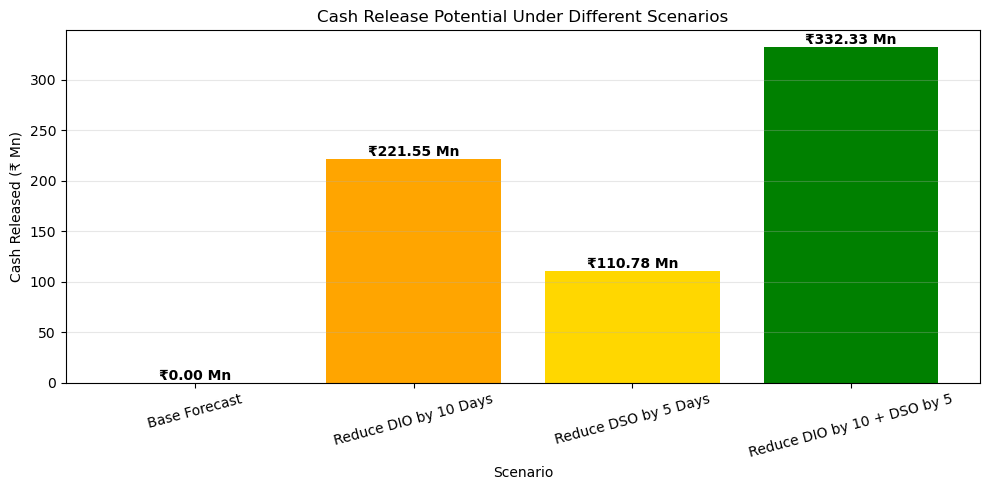

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    scenario_analysis["Scenario"],
    scenario_analysis["Cash Released (M)"],
    color=["grey", "orange", "gold", "green"]
)

plt.title("Cash Release Potential Under Different Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Cash Released (₹ Mn)")
plt.xticks(rotation=15)

# Show money values on bars
for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"₹{value:,.2f} Mn",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()


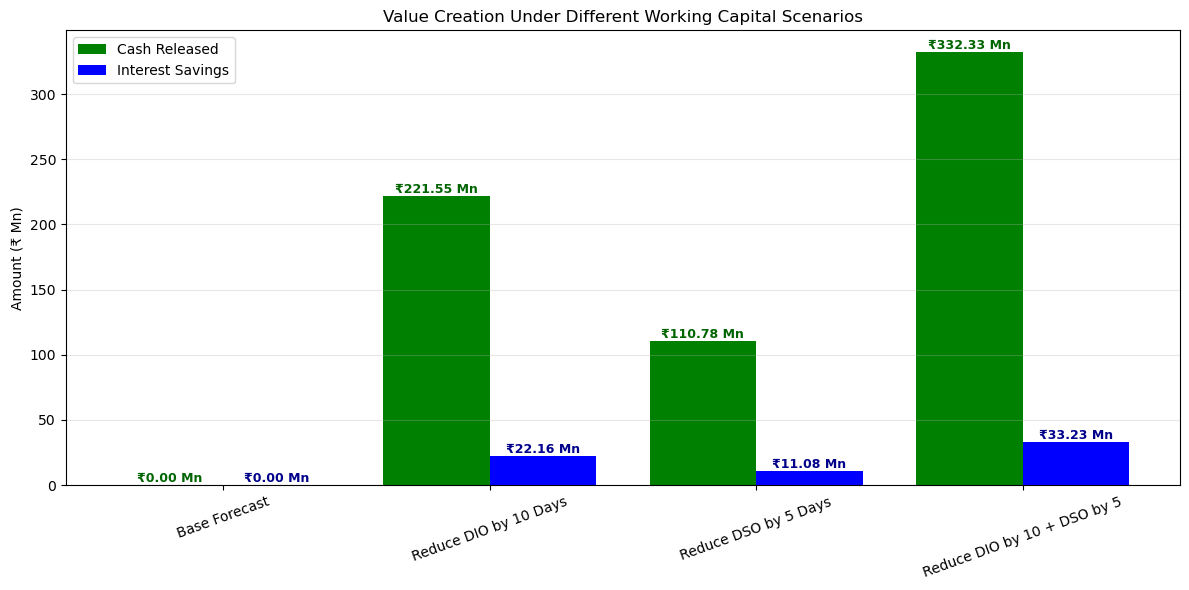

In [119]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(scenario_analysis))
width = 0.4

plt.figure(figsize=(12,6))

cash_bars = plt.bar(
    x - width/2,
    scenario_analysis["Cash Released (M)"],
    width,
    label="Cash Released",
    color="green"
)

interest_bars = plt.bar(
    x + width/2,
    scenario_analysis["Interest Savings (M)"],
    width,
    label="Interest Savings",
    color="blue"
)

# Cash Released Labels
for bar in cash_bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"₹{value:,.2f} Mn",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="darkgreen"
    )

# Interest Savings Labels
for bar in interest_bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"₹{value:,.2f} Mn" ,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="darkblue"
    )

plt.xticks(
    x,
    scenario_analysis["Scenario"],
    rotation=20
)

plt.title(
    "Value Creation Under Different Working Capital Scenarios"
)

plt.ylabel("Amount (₹ Mn)")
plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [107]:
best_scenario = scenario_analysis.loc[
    scenario_analysis["Cash Released (M)"].idxmax()
]

print(
    f"Maximum cash release of "
    f"{best_scenario['Cash Released (M)']:.2f} Mn "
    f"is achieved under the "
    f"{best_scenario['Scenario']} scenario."
)

Maximum cash release of 332.33 Mn is achieved under the Reduce DIO by 10 + DSO by 5 scenario.


In [121]:
import streamlit as st
import pandas as pd
import plotly.express as px

# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="Centum Working Capital Command Center",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Centum Working Capital Command Center")
st.markdown(
"""
### Forecast • Benchmark • Optimize • Create Value
"""
)

# ==========================================
# INPUT DATA
# ==========================================

forecast_revenue = 8086.73
forecast_dso = 119.45
forecast_dio = 261.27
forecast_dpo = 132.21
forecast_ccc = 248.51

benchmark_ccc = 149.54
benchmark_dso = 91.19
benchmark_dio = 177.83
benchmark_dpo = 119.49

gap_ccc = 103.18

benchmark_df = pd.DataFrame({
    "Company":[
        "Kaynes Technologies",
        "Centum",
        "Astra",
        "Apollo Micro Systems",
        "Datapatterns"
    ],
    "Avg CCC":[
        149.54,
        252.72,
        422.08,
        489.20,
        868.91
    ]
})

# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.header("Scenario Inputs")

interest_rate = st.sidebar.slider(
    "Interest Rate (%)",
    1.0,
    20.0,
    10.0
)

dio_reduction = st.sidebar.slider(
    "Reduce DIO By (Days)",
    0,
    60,
    10
)

dso_reduction = st.sidebar.slider(
    "Reduce DSO By (Days)",
    0,
    30,
    5
)

dpo_increase = st.sidebar.slider(
    "Increase DPO By (Days)",
    0,
    30,
    0
)

# ==========================================
# TABS
# ==========================================

tab1,tab2,tab3,tab4,tab5,tab6,tab7,tab8 = st.tabs([
    "Executive Summary",
    "Forecasting",
    "Benchmarking",
    "Gap Analysis",
    "Opportunity Ranking",
    "Scenario Simulator",
    "Value Creation",
    "Sensitivity Analysis"
])

# ======================================================
# TAB 1
# ======================================================

with tab1:

    st.subheader("Executive KPI Summary")

    c1,c2,c3,c4,c5 = st.columns(5)

    c1.metric(
        "FY2026 Revenue",
        f"₹{forecast_revenue:,.2f} Mn"
    )

    c2.metric(
        "Forecast CCC",
        f"{forecast_ccc:.2f} Days"
    )

    c3.metric(
        "Benchmark CCC",
        f"{benchmark_ccc:.2f}"
    )

    c4.metric(
        "CCC Gap",
        f"{gap_ccc:.2f}"
    )

    c5.metric(
        "Top Driver",
        "DIO"
    )

# ======================================================
# TAB 2
# ======================================================

with tab2:

    st.subheader("Forecast Summary")

    final_forecast = pd.DataFrame({
        "Financial Year":[
            "FY2026F",
            "FY2027F",
            "FY2028F"
        ],
        "Revenue (M)":[
            8086.73,
            8571.69,
            9056.66
        ],
        "DSO":[119.45]*3,
        "DIO":[261.27]*3,
        "DPO":[132.21]*3,
        "CCC":[248.51]*3
    })

    st.dataframe(
        final_forecast,
        use_container_width=True
    )

# ======================================================
# TAB 3
# ======================================================

with tab3:

    st.subheader("Peer Benchmarking")

    st.dataframe(
        benchmark_df,
        use_container_width=True
    )

    fig = px.bar(
        benchmark_df,
        x="Company",
        y="Avg CCC",
        color="Avg CCC",
        text="Avg CCC",
        color_continuous_scale="RdYlGn_r",
        title="Peer CCC Benchmarking"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

# ======================================================
# TAB 4
# ======================================================

with tab4:

    gap_table = pd.DataFrame({
        "Metric":[
            "DSO",
            "DIO",
            "DPO",
            "CCC"
        ],
        "Benchmark":[
            91.19,
            177.83,
            119.49,
            149.54
        ],
        "Centum":[
            113.94,
            269.70,
            130.93,
            252.72
        ],
        "Gap":[
            22.75,
            91.87,
            11.44,
            103.18
        ]
    })

    st.dataframe(
        gap_table,
        use_container_width=True
    )

# ======================================================
# TAB 5
# ======================================================

with tab5:

    opportunity_df = pd.DataFrame({
        "Driver":[
            "DIO",
            "DSO",
            "DPO"
        ],
        "Opportunity":[
            91.87,
            22.75,
            -11.44
        ]
    })

    fig = px.bar(
        opportunity_df,
        x="Driver",
        y="Opportunity",
        text="Opportunity",
        color="Opportunity",
        title="Opportunity Ranking Across CCC Drivers"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

# ======================================================
# TAB 6
# ======================================================

with tab6:

    revised_ccc = (
        (forecast_dso - dso_reduction)
        +
        (forecast_dio - dio_reduction)
        -
        (forecast_dpo + dpo_increase)
    )

    ccc_reduction = (
        forecast_ccc - revised_ccc
    )

    scenario_df = pd.DataFrame({
        "Metric":[
            "Current CCC",
            "Optimized CCC",
            "Reduction"
        ],
        "Value":[
            forecast_ccc,
            revised_ccc,
            ccc_reduction
        ]
    })

    st.dataframe(
        scenario_df,
        use_container_width=True
    )

# ======================================================
# TAB 7
# ======================================================

with tab7:

    cash_release = (
        forecast_revenue / 360
    ) * ccc_reduction

    interest_saved = (
        cash_release
        * interest_rate
        / 100
    )

    k1,k2,k3,k4 = st.columns(4)

    k1.metric(
        "Optimized CCC",
        f"{revised_ccc:.2f}"
    )

    k2.metric(
        "CCC Reduction",
        f"{ccc_reduction:.2f} Days"
    )

    k3.metric(
        "Cash Released",
        f"₹{cash_release:,.2f} Mn"
    )

    k4.metric(
        "Interest Savings",
        f"₹{interest_saved:,.2f} Mn"
    )

# ======================================================
# TAB 8
# ======================================================

with tab8:

    sensitivity_df = pd.DataFrame({
        "Company":[
            "Centum",
            "Astra",
            "Datapatterns",
            "Kaynes Technologies",
            "Apollo Micro Systems"
        ],
        "Avg CCC":[
            252.72,
            422.08,
            868.91,
            149.54,
            489.20
        ],
        "Rank (All Data)":[
            2,3,5,1,4
        ],
        "Avg9 CCC":[
            261.15,
            444.35,
            706.91,
            149.54,
            517.11
        ],
        "Rank (9Y)":[
            2,3,5,1,4
        ]
    })

    st.dataframe(
        sensitivity_df,
        use_container_width=True
    )

# ======================================================
# RECOMMENDATION
# ======================================================

st.markdown("---")

st.subheader("Executive Recommendation")

st.success(
f"""
✅ Inventory Optimization remains the highest-priority lever.

✅ Current Forecast CCC: {forecast_ccc:.2f} Days

✅ Optimized CCC: {revised_ccc:.2f} Days

✅ Cash Release Potential: ₹{cash_release:,.2f} Mn

✅ Interest Savings Potential: ₹{interest_saved:,.2f} Mn

✅ Recommended Focus:
Inventory Optimization (DIO) followed by Receivables Optimization (DSO).
"""
)

2026-08-16 09:35:33.754 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-16 09:35:33.756 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-16 09:35:34.513 
  command:

    streamlit run C:\Users\nagarajutk\AppData\Local\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-16 09:35:34.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-16 09:35:34.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-16 09:35:34.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-16 09:35:34.519 Thread 'MainThread': missing ScriptRunContext! This warning can b

DeltaGenerator()